## Notebook 206: does the HP-alphabet advantage track sequence divergence?

Notebooks [200](./200_human_mouse_ortholog_alphabet_ksize_comparison.ipynb) and
[211](./211_mhc_recovery_and_auc.ipynb) appear to disagree: genome-wide, HP alphabets rank *worst*
of the three alphabet families (200); on MHC class I/II, HP *dominates* (211). This notebook tests
a falsifiable mechanism that reconciles them.

**Mechanism.** A 2-letter HP alphabet absorbs amino-acid substitutions that a 20-letter protein
alphabet, or the intermediate dayhoff alphabet, treats as mismatches. The method cares *how many*
residues differ between a human protein and its mouse ortholog, not *why*, so the covariate is
**percent sequence identity**, not dN/dS. dN/dS's synonymous-site normalization removes information
relevant to a substitution-tolerance argument: a pair diverged by relaxed constraint poses the same
k-mer-mismatch problem as one diverged by positive selection.

**Prediction, stated before looking at results.** The HP-vs-protein/dayhoff performance gap should
*increase*, and eventually flip in HP's favor, as percent identity *drops*. MHC class I sits at the
high-divergence tail of the genome-wide distribution, so under this mechanism notebooks 200 and 211
are two points on one curve.

**A second axis, gene-family turnover (paralog count)**, separates two kinds of rapid evolution:
- **Rapid substitution** on a stable 1:1 ortholog pair (high divergence, low turnover) &rarr; HP
  *should help*.
- **Rapid birth-death turnover** (large lineage-specific paralog expansions) &rarr; HP *should
  hurt*, because collapsing residue identity is what makes near-identical paralogs
  indistinguishable.

So the mechanism predicts the HP advantage tracks **divergence** and is **flat or negative** against
**paralog count**.

**Scoring.** Every performance number below uses three already-implemented methods:
1. `score_bonf_neglogp_cont` (−log₁₀(Bonferroni p) × containment) as the ranking score for
   ROC-AUC/PR-AUC, the best-AUPRC composite from the repo's genome-wide scoring benchmark,
2. BH-significant calling (`score_bh_neglogq` / BH-adjusted p),
3. RBH F1, the same methodology as notebook 200.

`score_enr_cont_freq` (`enrichment × containment / freq`, the previous incumbent) is shown for
reference only.

**HP alphabets covered.** Seven encoding names (`ALL_HP_ENCODINGS`), each across its full k range
and drawn as an envelope rather than a single point: `hp`, `hp-lehninger`, `hp-thomas-dill`,
`hp-kyte-doolittle`, `hp-thomas-dill-no-c`, `hp-lehninger-plus-c`, `hp-pbotc-1st-ed`. **`hp` and
`hp-lehninger` are the same alphabet** — kmerseek's default HP *is* Lehninger
(`AFGILMPVWY` / `CDEHKNQRST` in `hp_alphabets.rs`), and notebook 200 found the two result files
byte-identical — so the seven names are six distinct alphabets, which is why the figures label the
envelope "6 variants". The median is nevertheless taken over all seven rows, so Lehninger carries
double weight in it. An `hp_thomas_dill`-underscore file set also exists on disk, but only for
k25/26, left over from earlier single-k index work; the dash-named `hp-thomas-dill` files have full
k18-30 coverage and are used throughout.

**Families used as illustrative anchors, not as the evidence** — the lead figure is the genome-wide
decile plot: olfactory receptors and CYP2/CYP3 (both via real HGNC `gene_group` membership, not
hand-picked lists), antiviral restriction factors (a named literature list verified against current
HGNC nomenclature), sperm/testis-specific proteins (Kopania et al. 2022, *MBE*, Table S12, with its
own broadly-expressed control group from the same table), and a recap of the MHC class I/II
analysis (notebooks 210-214).

In [1]:
import sys

sys.path.insert(0, ".")

import time
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

import ortholog_analysis_utils as u

DATA_DIR = u.DATA_DIR
OUT_DIR = Path("../figures")  # repo-level figures/, not notebooks/

mgi_pairs, mgi_set = u.load_mgi_orthologs()
human_to_mouse = {h: m for h, m in mgi_set}
mouse_to_human = {
    m: h for h, m in mgi_set
}  # NB collapses if a mouse gene has >1 human ortholog

hgnc = u.load_hgnc_gene_groups()

print(f"MGI ortholog pairs: {len(mgi_set):,}")
print(f"HGNC gene records: {hgnc.height:,}")

MGI ortholog pairs: 24,584
HGNC gene records: 45,030


## 1. Alphabet×k RBH-F1 coverage for the 6 new HP variants

Notebook 200's cached sweep (`200_alphabet_ksize_matched_scope_comparison.csv`) predates the
`hp-lehninger`, `hp-thomas-dill` (as `hp_thomas_dill`), `hp-kyte-doolittle`,
`hp-thomas-dill-no-c`, `hp-lehninger-plus-c`, and `hp-pbotc-1st-ed` sweep; it covers only
`protein`/`dayhoff`/`hp`. Those six variants are scored with the same methodology
(`rbh_pairs_and_scope` + `prf1` from `ortholog_analysis_utils.py`, matched-scope
precision/recall/F1 against MGI) across every k already computed on disk.

**The scoring runs in the Nextflow pipeline, not here.** `computeRbhF1` in
`nextflow-runs/human-mouse-gencode-orthologs/kmerseek_human_mouse_orthologs.nf` runs one task per
combo and writes the same `200_rbh_f1_all_combos.csv` that notebook 200 section 1 reads. It replaced
a sequential in-notebook loop that only ever finished 2 of the 6 variants. The cells below discover
which combos exist on disk and check them against that table; to add combos, rerun `make resume` in
the pipeline directory rather than running anything here.

In [2]:
import re
from datetime import datetime

NEW_HP_ENCODINGS = [
    "hp-lehninger",
    "hp-thomas-dill",
    "hp-kyte-doolittle",
    "hp-thomas-dill-no-c",
    "hp-lehninger-plus-c",
    "hp-pbotc-1st-ed",
]
ALL_HP_ENCODINGS = ["hp"] + NEW_HP_ENCODINGS

# Known landmine (see memory `pipeline_thomas_dill_empty_index_bug`): a dash/underscore
# normalisation bug in the ortholog pipeline (fixed 2026-07-21) previously caused
# hp-thomas-dill, hp-kyte-doolittle, hp-lehninger-plus-c, hp-thomas-dill-no-c to silently
# index as EMPTY. Files are also legitimately near-empty at low k under kmerseek 0.4.0's
# "skip insignificant hits" behavior (13-byte zst = zero rows, not a bug) — either way,
# exclude anything under MIN_BYTES from the usable k range rather than trying to score it.
FIX_DATE = datetime(2026, 7, 21)
MIN_BYTES = 10_000_000

file_re = re.compile(
    r"human_vs_mouse\.(.+?)\.k(\d+)\.results\.(?:csv\.(?:zst|gz)|parquet)$"
)
all_files: dict[str, dict[int, Path]] = {}
# .parquet-first: hp-pbotc-1st-ed k=19 (10GB, converted straight to parquet -- no
# .csv.zst was ever written for it, unlike every other k for this encoding) had NO
# match under the old csv.zst/.gz-only glob, so it silently never entered the sweep or
# any downstream comparison in this notebook. Glob .parquet first so it wins when a
# combo has both formats, matching u.rbh_pairs_and_scope's own format preference.
for pattern in ["human_vs_mouse.*.results.parquet", "human_vs_mouse.*.results.csv.*"]:
    for f in DATA_DIR.glob(pattern):
        m = file_re.match(f.name)
        if not m:
            continue
        enc, k = m.groups()
        all_files.setdefault(enc, {}).setdefault(int(k), f)

available: dict[str, dict[int, Path]] = {
    enc: {k: f for k, f in files.items() if f.stat().st_size >= MIN_BYTES}
    for enc, files in all_files.items()
}

print(
    f"{'encoding':24s} {'usable k range':20s} {'n_k':>4s}  dropped (near-empty)  pre-fix k's"
)
for enc in ["protein", "dayhoff"] + ALL_HP_ENCODINGS:
    files = available.get(enc, {})
    ks = sorted(files)
    dropped = sorted(set(all_files.get(enc, {})) - set(files))
    pre_fix = [
        k
        for k, f in files.items()
        if datetime.fromtimestamp(f.stat().st_mtime) < FIX_DATE
    ]
    k_range = f"{ks[0]}-{ks[-1]}" if ks else "MISSING"
    print(f"{enc:24s} {k_range:20s} {len(ks):>4d}  {dropped or '-'}  {pre_fix or '-'}")

encoding                 usable k range        n_k  dropped (near-empty)  pre-fix k's
protein                  5-15                   11  -  -
dayhoff                  10-20                  11  -  -
hp                       21-30                   8  -  [29, 26, 27, 28, 22, 30, 24]
hp-lehninger             18-30                  13  -  -
hp-thomas-dill           20-30                  11  -  -
hp-kyte-doolittle        20-30                  11  -  -
hp-thomas-dill-no-c      20-30                  11  -  -
hp-lehninger-plus-c      18-30                  13  -  -
hp-pbotc-1st-ed          19-30                  12  -  -


**Coverage check.** Which of the combos discovered above the pipeline's RBH-F1 table actually
covers. Anything missing is filled by rerunning the pipeline, not this notebook.

In [3]:
# Coverage check only -- the actual scoring now happens in the pipeline (computeRbhF1),
# reading from the same 200_rbh_f1_all_combos.csv notebook 200 §1 reads. This replaces the
# old sequential sweep loop that checkpointed to 206_alphabet_ksize_rbh_sweep_extended.csv and
# only ever got 2/6 new HP variants done.
rbh_f1_all = pl.read_csv(DATA_DIR / "200_rbh_f1_all_combos.csv")
covered = set(zip(rbh_f1_all["encoding"].to_list(), rbh_f1_all["ksize"].to_list()))

n_possible = sum(len(available.get(e, {})) for e in NEW_HP_ENCODINGS)
n_covered = sum(
    1 for enc in NEW_HP_ENCODINGS for k in available.get(enc, {}) if (enc, k) in covered
)
print(
    f"{n_covered}/{n_possible} new-HP-variant combos covered by the pipeline's RBH-F1 table "
    + (
        "(COMPLETE)"
        if n_covered == n_possible
        else "(PARTIAL -- rerun the pipeline to fill the rest)"
    )
)

0/71 new-HP-variant combos covered by the pipeline's RBH-F1 table (PARTIAL -- rerun the pipeline to fill the rest)


## 2. Percent-identity covariate

Primary source: `120_annotation_results.csv` (`perc_id`, already populated for a subset of MGI
pairs). Gaps are filled from Ensembl BioMart's `mmusculus_homolog_perc_id` attribute, batched by
human ENSG ID. BioMart still serves percent identity, unlike dN/dS, which was discontinued
genome-wide at Release 100. BioMart reports both directions (human-vs-mouse and mouse-vs-human,
which differ slightly due to alignment length asymmetry); live fetches average the two.

In [4]:
# Cached perc_id from earlier work
ann = pl.read_csv(DATA_DIR / "120_annotation_results.csv")
cached_pid = (
    ann.filter(pl.col("perc_id").is_not_null())
    .with_columns(
        [
            pl.col("human_gene_name").str.to_uppercase().alias("human_gene"),
            pl.col("mouse_gene_name").str.to_uppercase().alias("mouse_gene"),
        ]
    )
    .group_by(["human_gene", "mouse_gene"])
    .agg(pl.col("perc_id").median().alias("perc_id"))
)
cached_pid_set = set(
    zip(cached_pid["human_gene"].to_list(), cached_pid["mouse_gene"].to_list())
)

# Human gene symbol -> ENSG, needed to query BioMart for the gap. Reuse the protein k15
# genome-wide file (smallest, already scanned) rather than a separate annotation download.
human_ids = u.extract_ids(
    u.scan_genome_wide_results("protein", 15, columns=["query_name"])
    .unique()
    .collect()["query_name"]
)
symbol_to_ensg = dict(
    zip(
        human_ids["gene_name"].str.to_uppercase().to_list(),
        human_ids["gene_id"].to_list(),
    )
)

missing_pairs = [(h, m) for h, m in mgi_set if (h, m) not in cached_pid_set]
missing_with_ensg = [
    (h, m, symbol_to_ensg[h]) for h, m in missing_pairs if h in symbol_to_ensg
]
print(
    f"MGI pairs: {len(mgi_set):,} | cached perc_id: {len(cached_pid_set):,} | "
    f"missing: {len(missing_pairs):,} | missing w/ ENSG (fetchable): {len(missing_with_ensg):,}"
)

MGI pairs: 24,584 | cached perc_id: 16,702 | missing: 7,940 | missing w/ ENSG (fetchable): 2,828


In [5]:
PERCID_CACHE = DATA_DIR / "206_percid_cache.csv"

if PERCID_CACHE.exists():
    percid_df = pl.read_csv(str(PERCID_CACHE))
else:
    unique_ensg = sorted({ensg for _, _, ensg in missing_with_ensg})
    print(f"Fetching perc_id for {len(unique_ensg):,} human ENSG IDs from BioMart...")
    fetched = u.fetch_biomart_perc_id(unique_ensg)
    print(f"BioMart returned values for {len(fetched):,}/{len(unique_ensg):,}")

    live_rows = [
        {"human_gene": h, "mouse_gene": m, "perc_id": fetched[ensg]}
        for h, m, ensg in missing_with_ensg
        if ensg in fetched
    ]
    percid_df = pl.concat(
        [
            cached_pid.select(["human_gene", "mouse_gene", "perc_id"]).with_columns(
                pl.lit("cached_120").alias("source")
            ),
            (
                pl.DataFrame(live_rows).with_columns(
                    pl.lit("biomart_live").alias("source")
                )
                if live_rows
                else pl.DataFrame(
                    schema={
                        "human_gene": pl.Utf8,
                        "mouse_gene": pl.Utf8,
                        "perc_id": pl.Float64,
                        "source": pl.Utf8,
                    }
                )
            ),
        ]
    )
    percid_df.write_csv(str(PERCID_CACHE))

n_covered = percid_df.height
print(
    f"perc_id covariate: {n_covered:,}/{len(mgi_set):,} MGI pairs "
    f"({100*n_covered/len(mgi_set):.1f}%) — source breakdown:"
)
print(percid_df.group_by("source").len().sort("len", descending=True))

perc_id covariate: 18,152/24,584 MGI pairs (73.8%) — source breakdown:
shape: (2, 2)
┌──────────────┬───────┐
│ source       ┆ len   │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ cached_120   ┆ 16702 │
│ biomart_live ┆ 1450  │
└──────────────┴───────┘


## 3. Decile plot (lead figure)

Human genes are binned into percent-identity deciles, using the max `perc_id` across a gene's MGI
partners for the rare paralog-collision case. Within each decile, RBH-F1 is recomputed as in
notebook 200 but restricted to that decile's human genes: both the called RBH set and the MGI truth
set are filtered to the decile, so both true and false calls are counted.

Protein (k=15) and dayhoff (k=20), the best k from notebook 200, are computed fresh here (small
files). Each HP variant is drawn as its own line, never collapsed into a median envelope, built
from every (encoding, ksize) pair cached by the section 1 sweep. If that sweep has not finished,
only the cached variants appear, which is reported rather than plotted as if complete.

In [6]:
# Human gene -> decile. Collapsed with MEDIAN across a gene's MGI partner(s), matching
# ou.collapse_perc_id's default and notebook 215's PRIMARY_PERC_ID_POLICY.
#
# This used to be max(). That is an extreme order statistic -- E[max of N] rises with N -- so a
# one-to-many gene was pushed into a higher-identity decile by the very expansion that makes it
# a hard case, while a 1:1 gene got its single honest value. MHC class I (up to 15 mouse
# partners) was the worst affected, and it is exactly the family this notebook's argument turns
# on. Two other cells in this notebook collapsed the same quantity with median and mean, so the
# ledger's perc_id covariate was not comparable across its own rows.
gene_pid = percid_df.group_by("human_gene").agg(
    pl.col("perc_id").median().alias("perc_id")
)
n_deciles = 10
gene_pid = gene_pid.with_columns(
    (pl.col("perc_id").rank(method="ordinal") / gene_pid.height * n_deciles)
    .ceil()
    .clip(1, n_deciles)
    .cast(pl.Int64)
    .alias("decile")
)
decile_genes: dict[int, set[str]] = {
    d: set(gene_pid.filter(pl.col("decile") == d)["human_gene"].to_list())
    for d in range(1, n_deciles + 1)
}
decile_ranges = (
    gene_pid.group_by("decile")
    .agg(
        [
            pl.col("perc_id").min().alias("lo"),
            pl.col("perc_id").max().alias("hi"),
            pl.len().alias("n"),
        ]
    )
    .sort("decile")
)
print(f"{gene_pid.height:,} human genes with a perc_id-derived decile")
print(decile_ranges)


def decile_prf1(
    rbh_set: set, full_scope: set, decile_genes_: set, mgi_set_: set
) -> tuple[float, float, float, int]:
    """RBH precision/recall/F1 restricted to human genes in one decile (both correct and
    incorrect calls for those genes count — see markdown above)."""
    eval_scope = full_scope & decile_genes_
    truth = {(h, m) for h, m in mgi_set_ if h in eval_scope}
    called = {(h, m) for h, m in rbh_set if h in eval_scope}
    p, r, f1, tp, fp, fn = u.prf1(called, truth)
    return p, r, f1, len(eval_scope)

16,714 human genes with a perc_id-derived decile
shape: (10, 4)
┌────────┬─────────┬─────────┬──────┐
│ decile ┆ lo      ┆ hi      ┆ n    │
│ ---    ┆ ---     ┆ ---     ┆ ---  │
│ i64    ┆ f64     ┆ f64     ┆ u32  │
╞════════╪═════════╪═════════╪══════╡
│ 1      ┆ 3.77734 ┆ 66.4671 ┆ 1671 │
│ 2      ┆ 66.4804 ┆ 74.6269 ┆ 1671 │
│ 3      ┆ 74.6269 ┆ 79.9114 ┆ 1672 │
│ 4      ┆ 79.9213 ┆ 83.6697 ┆ 1671 │
│ 5      ┆ 83.6703 ┆ 87.0445 ┆ 1672 │
│ 6      ┆ 87.0445 ┆ 89.9417 ┆ 1671 │
│ 7      ┆ 89.9417 ┆ 92.6923 ┆ 1671 │
│ 8      ┆ 92.6941 ┆ 95.1362 ┆ 1672 │
│ 9      ┆ 95.1389 ┆ 97.4771 ┆ 1671 │
│ 10     ┆ 97.4777 ┆ 100.0   ┆ 1672 │
└────────┴─────────┴─────────┴──────┘


In [7]:
# Protein/dayhoff best-k (established in notebook 200) — cheap, computed fresh
BEST_PROTEIN_K, BEST_DAYHOFF_K = 15, 20
protein_rbh, protein_scope = u.rbh_pairs_and_scope("protein", BEST_PROTEIN_K)
dayhoff_rbh, dayhoff_scope = u.rbh_pairs_and_scope("dayhoff", BEST_DAYHOFF_K)

protein_decile_f1 = [
    decile_prf1(protein_rbh, protein_scope, decile_genes[d], mgi_set)[2]
    for d in range(1, 11)
]
dayhoff_decile_f1 = [
    decile_prf1(dayhoff_rbh, dayhoff_scope, decile_genes[d], mgi_set)[2]
    for d in range(1, 11)
]

# HP variants — every (encoding, ksize) combo with real genome-wide results on disk (`available`,
# cell above). Kept as one line PER VARIANT (never collapsed into a single median/range
# envelope) so each alphabet's own divergence-response shape stays visible.
# Needs BOTH the RBH pairs and the file's full scope (genes with any hit, not just
# RBH-called ones) — restricting eval_scope to only RBH-called genes would silently
# drop FN cases (a gene with hits but no correct RBH call) and inflate F1.
#
# 2026-08-11: calls ou.rbh_pairs_and_scope directly per combo instead of reading a separate
# 206_hp_variant_rbh_pairs.parquet/206_hp_variant_scope.parquet cache built by the old sweep
# loop. That's cheap now: ou.load_pair_table's own pair_cache/ is already populated for every
# combo as a side effect of the pipeline's computeRbhF1 having scanned each raw file once, so
# this is a small cached-parquet read + fast in-memory RBH join, not a multi-GB rescan.
hp_combos = [
    (enc, k) for enc in NEW_HP_ENCODINGS for k in sorted(available.get(enc, {}))
]
n_possible = len(hp_combos)

hp_decile_f1_by_combo: dict[tuple[str, int], list[float]] = {}
for enc, k in hp_combos:
    rbh_set, scope = u.rbh_pairs_and_scope(enc, k, DATA_DIR)
    hp_decile_f1_by_combo[(enc, k)] = [
        decile_prf1(rbh_set, scope, decile_genes[d], mgi_set)[2] for d in range(1, 11)
    ]

print(
    f"HP variants built from {len(hp_combos)}/{n_possible} available (encoding, ksize) combos"
)

# One line per HP variant. If a variant has more than one cached k (sweep still filling in),
# take the median across its k's rather than picking one arbitrarily.
hp_encodings_present = [
    enc for enc in NEW_HP_ENCODINGS if any(e == enc for e, _ in hp_combos)
]
hp_ks_by_encoding: dict[str, list[int]] = {
    enc: sorted(k for e, k in hp_combos if e == enc) for enc in hp_encodings_present
}
hp_decile_f1_by_encoding: dict[str, list[float]] = {
    enc: np.median(
        [hp_decile_f1_by_combo[(enc, k)] for k in hp_ks_by_encoding[enc]], axis=0
    ).tolist()
    for enc in hp_encodings_present
}
for enc in hp_encodings_present:
    print(f"  {enc:24s} k={hp_ks_by_encoding[enc]}")

# Dedicated hp-pbotc-1st-ed @ k=19 line, kept SEPARATE from the per-encoding median
# above: once section 1's sweep has all of k19-30 for this variant, that median would
# blend k=19 in with the higher-k results, washing out the specific low-k signal this
# notebook is trying to show (notebook 211 found k=19 uniquely strong on MHC class I,
# the highest-divergence anchor available). Read directly from hp_decile_f1_by_combo
# instead of folding it into hp_decile_f1_by_encoding.
PBOTC_K19 = ("hp-pbotc-1st-ed", 19)
pbotc_k19_decile_f1 = hp_decile_f1_by_combo.get(PBOTC_K19)
print(
    f"hp-pbotc-1st-ed @ k=19 dedicated decile line: "
    f"{'available' if pbotc_k19_decile_f1 is not None else 'NOT YET CACHED -- rerun the pipeline'}"
)

HP variants built from 71/71 available (encoding, ksize) combos
  hp-lehninger             k=[18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
  hp-thomas-dill           k=[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
  hp-kyte-doolittle        k=[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
  hp-thomas-dill-no-c      k=[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
  hp-lehninger-plus-c      k=[18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
  hp-pbotc-1st-ed          k=[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
hp-pbotc-1st-ed @ k=19 dedicated decile line: available


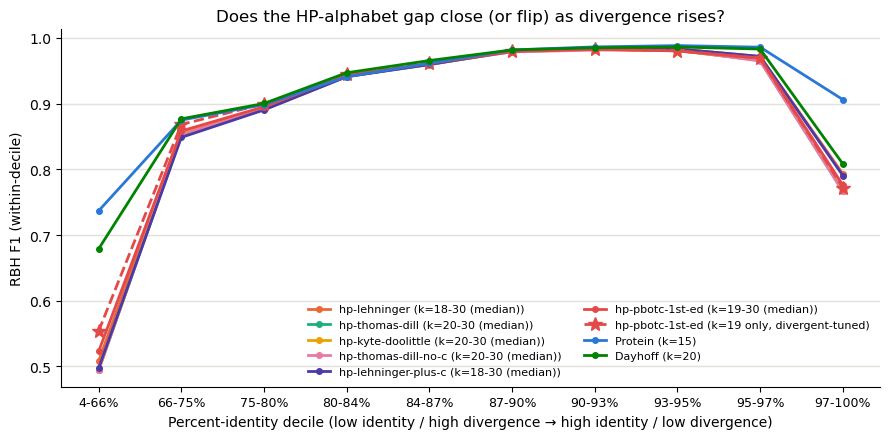

In [8]:
BLUE, GREEN, ORANGE = "#2a78d6", "#008300", "#eb6834"
# Fixed categorical order (never cycled/reassigned) — slots 2,3,4,5,7,8 of the repo's
# validated 8-hue palette (slots 1=blue, 6=green already used for protein/dayhoff above).
HP_COLORS = {
    "hp-lehninger": "#eb6834",  # orange
    "hp-thomas-dill": "#1baf7a",  # aqua
    "hp-kyte-doolittle": "#eda100",  # yellow
    "hp-thomas-dill-no-c": "#e87ba4",  # magenta
    "hp-lehninger-plus-c": "#4a3aa7",  # violet
    "hp-pbotc-1st-ed": "#e34948",  # red
}

x = np.arange(1, n_deciles + 1)
fig, ax = plt.subplots(figsize=(9, 4.5))
for enc in hp_encodings_present:
    ks = hp_ks_by_encoding[enc]
    k_label = f"k={ks[0]}" if len(ks) == 1 else f"k={ks[0]}-{ks[-1]} (median)"
    ax.plot(
        x,
        hp_decile_f1_by_encoding[enc],
        color=HP_COLORS[enc],
        lw=2,
        marker="o",
        ms=4,
        label=f"{enc} ({k_label})",
    )
if pbotc_k19_decile_f1 is not None:
    # Drawn on top of (not folded into) hp-pbotc-1st-ed's own median line above -- see
    # the comment in the previous cell for why this variant gets a second, unblended line.
    ax.plot(
        x,
        pbotc_k19_decile_f1,
        color=HP_COLORS["hp-pbotc-1st-ed"],
        lw=2,
        ls="--",
        marker="*",
        ms=10,
        label="hp-pbotc-1st-ed (k=19 only, divergent-tuned)",
    )
ax.plot(
    x,
    protein_decile_f1,
    color=BLUE,
    lw=2,
    marker="o",
    ms=4,
    label=f"Protein (k={BEST_PROTEIN_K})",
)
ax.plot(
    x,
    dayhoff_decile_f1,
    color=GREEN,
    lw=2,
    marker="o",
    ms=4,
    label=f"Dayhoff (k={BEST_DAYHOFF_K})",
)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{lo:.0f}-{hi:.0f}%" for lo, hi in zip(decile_ranges["lo"], decile_ranges["hi"])],
    fontsize=9,
)
ax.set_xlabel(
    "Percent-identity decile (low identity / high divergence → high identity / low divergence)"
)
ax.set_ylabel("RBH F1 (within-decile)")
ax.set_title("Does the HP-alphabet gap close (or flip) as divergence rises?")
ax.grid(axis="y", color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc="lower right", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "206_decile_plot.png", dpi=150)
plt.show()

**Numbers behind the decile plot, and the gap in isolation.** The figure above shows raw F1 per
encoding. The table below gives the per-decile values, and the figure after it isolates
&Delta;F1 = HP median &minus; protein/dayhoff, the quantity the mechanism predicts should move
toward HP as identity drops. Subject to the partial-sweep caveat printed above: not every HP variant
has genome-wide k coverage cached yet, so this is an early look.

In [9]:
decile_table = pl.DataFrame(
    {
        "decile": list(range(1, n_deciles + 1)),
        "pct_id_lo": decile_ranges["lo"].to_list(),
        "pct_id_hi": decile_ranges["hi"].to_list(),
        "n_genes": decile_ranges["n"].to_list(),
        "protein_f1": protein_decile_f1,
        "dayhoff_f1": dayhoff_decile_f1,
        **{f"{enc}_f1": hp_decile_f1_by_encoding[enc] for enc in hp_encodings_present},
        **(
            {"hp_pbotc_1st_ed_k19_f1": pbotc_k19_decile_f1}
            if pbotc_k19_decile_f1 is not None
            else {}
        ),
    }
)
hp_median_decile_f1 = (
    np.median([hp_decile_f1_by_encoding[enc] for enc in hp_encodings_present], axis=0)
    if hp_encodings_present
    else np.full(n_deciles, np.nan)
)
decile_table = decile_table.with_columns(
    [
        pl.Series("hp_median_f1", hp_median_decile_f1),
        pl.Series("gap_vs_protein", hp_median_decile_f1 - np.array(protein_decile_f1)),
        pl.Series("gap_vs_dayhoff", hp_median_decile_f1 - np.array(dayhoff_decile_f1)),
    ]
)
if pbotc_k19_decile_f1 is not None:
    decile_table = decile_table.with_columns(
        [
            (pl.Series(pbotc_k19_decile_f1) - pl.Series(protein_decile_f1)).alias(
                "pbotc_k19_gap_vs_protein"
            ),
            (pl.Series(pbotc_k19_decile_f1) - pl.Series(dayhoff_decile_f1)).alias(
                "pbotc_k19_gap_vs_dayhoff"
            ),
        ]
    )
print(
    f"Decile F1 table ({len(hp_encodings_present)}/{len(NEW_HP_ENCODINGS)} new HP variants cached — "
    f"{'COMPLETE' if len(hp_encodings_present) == len(NEW_HP_ENCODINGS) else 'PARTIAL, see section 1'})"
)
decile_table

Decile F1 table (6/6 new HP variants cached — COMPLETE)


decile,pct_id_lo,pct_id_hi,n_genes,protein_f1,dayhoff_f1,hp-lehninger_f1,hp-thomas-dill_f1,hp-kyte-doolittle_f1,hp-thomas-dill-no-c_f1,hp-lehninger-plus-c_f1,hp-pbotc-1st-ed_f1,hp_pbotc_1st_ed_k19_f1,hp_median_f1,gap_vs_protein,gap_vs_dayhoff,pbotc_k19_gap_vs_protein,pbotc_k19_gap_vs_dayhoff
i64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,3.77734,66.4671,1671,0.736802,0.67881,0.507981,0.494797,0.493967,0.493851,0.497164,0.522819,0.553783,0.495981,-0.240822,-0.182829,-0.183019,-0.125027
2,66.4804,74.6269,1671,0.874883,0.876818,0.857308,0.850729,0.854233,0.853078,0.848573,0.85834,0.868293,0.853656,-0.021227,-0.023162,-0.00659,-0.008525
3,74.6269,79.9114,1672,0.898653,0.900232,0.892343,0.891511,0.891066,0.891386,0.890364,0.895205,0.899571,0.891448,-0.007204,-0.008784,0.000918,-0.000661
4,79.9213,83.6697,1671,0.940859,0.946961,0.941597,0.941632,0.941001,0.941597,0.940931,0.943222,0.944742,0.941597,0.000739,-0.005364,0.003883,-0.002219
5,83.6703,87.0445,1672,0.961286,0.965579,0.959263,0.959833,0.96019,0.961024,0.959548,0.96119,0.962567,0.960012,-0.001275,-0.005567,0.00128,-0.003012
6,87.0445,89.9417,1671,0.981731,0.98172,0.980228,0.979004,0.979335,0.978711,0.979886,0.979641,0.980251,0.979488,-0.002243,-0.002232,-0.00148,-0.001469
7,89.9417,92.6923,1671,0.986301,0.985092,0.983577,0.982697,0.982404,0.981481,0.983881,0.982687,0.98299,0.982692,-0.00361,-0.002401,-0.003311,-0.002102
8,92.6941,95.1362,1672,0.988334,0.986194,0.983193,0.981064,0.980439,0.981676,0.983193,0.980156,0.980475,0.98137,-0.006964,-0.004824,-0.007859,-0.00572
9,95.1389,97.4771,1671,0.985941,0.983051,0.971635,0.965726,0.966333,0.964806,0.971929,0.969166,0.969147,0.967749,-0.018191,-0.015302,-0.016794,-0.013904


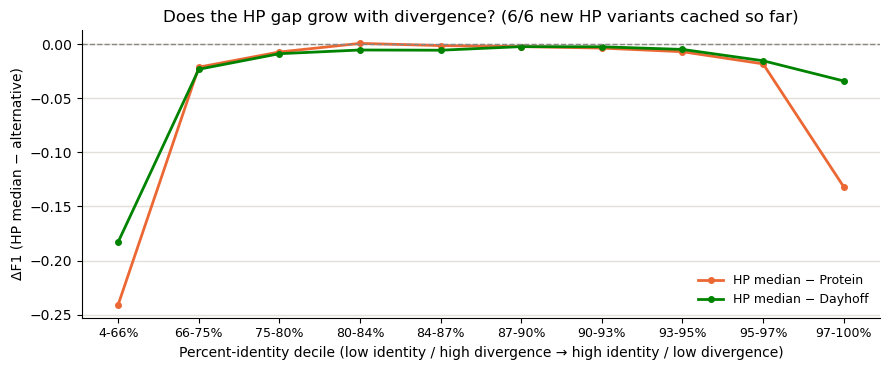

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(
    x,
    decile_table["gap_vs_protein"],
    color=ORANGE,
    lw=2,
    marker="o",
    ms=4,
    label="HP median − Protein",
)
ax.plot(
    x,
    decile_table["gap_vs_dayhoff"],
    color=GREEN,
    lw=2,
    marker="o",
    ms=4,
    label="HP median − Dayhoff",
)
ax.axhline(0, color="#898781", lw=1, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{lo:.0f}-{hi:.0f}%" for lo, hi in zip(decile_ranges["lo"], decile_ranges["hi"])],
    fontsize=9,
)
ax.set_xlabel(
    "Percent-identity decile (low identity / high divergence → high identity / low divergence)"
)
ax.set_ylabel("ΔF1 (HP median − alternative)")
ax.set_title(
    f"Does the HP gap grow with divergence? ({len(hp_encodings_present)}/{len(NEW_HP_ENCODINGS)} new HP variants cached so far)"
)
ax.grid(axis="y", color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc="best", fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "206_decile_gap.png", dpi=150)
plt.show()

## 3b. Close vs divergent orthologs, head-to-head

The decile plot shows the full curve; this collapses it to the two extremes the claim rests on:
decile 1 (lowest percent identity, most divergent) versus decile 10 (most conserved), as a grouped
bar chart. `hp-pbotc-1st-ed` appears twice on purpose — once via its k=19 line from section 3
(excluded from the other variants' median-across-k envelope) and once folded into "HP median" like
every other variant. The gap between those two bars is the claim being tested: k=19 buys something
at low identity that is diluted once averaged with its own higher-k results.

Close = decile 10 (97-100% identity), Divergent = decile 1 (4-66% identity)
shape: (4, 4)
┌────────────────────────┬──────────┬──────────────┬───────────────────────┐
│ alphabet               ┆ close_f1 ┆ divergent_f1 ┆ divergent_minus_close │
│ ---                    ┆ ---      ┆ ---          ┆ ---                   │
│ str                    ┆ f64      ┆ f64          ┆ f64                   │
╞════════════════════════╪══════════╪══════════════╪═══════════════════════╡
│ Protein                ┆ 0.906184 ┆ 0.736802     ┆ -0.169382             │
│ Dayhoff                ┆ 0.808322 ┆ 0.67881      ┆ -0.129512             │
│ HP median (6 variants) ┆ 0.774318 ┆ 0.495981     ┆ -0.278337             │
│ hp-pbotc-1st-ed (k=19) ┆ 0.772297 ┆ 0.553783     ┆ -0.218514             │
└────────────────────────┴──────────┴──────────────┴───────────────────────┘


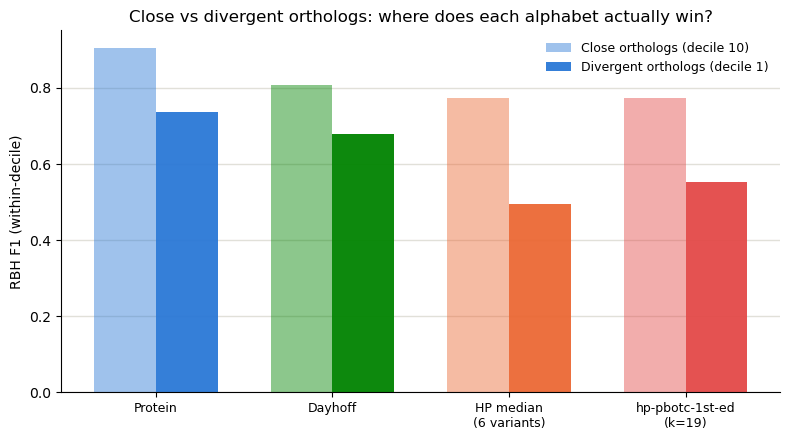

In [11]:
# Close-vs-divergent summary, collapsed from decile_table above: decile 1 (most
# divergent) vs decile n_deciles (most conserved). Uses the SAME F1 numbers as the
# decile plot -- nothing recomputed here.
close_decile, divergent_decile = n_deciles, 1
bars = [
    ("Protein", protein_decile_f1, BLUE),
    ("Dayhoff", dayhoff_decile_f1, GREEN),
    ("HP median\n(6 variants)", hp_median_decile_f1.tolist(), ORANGE),
]
if pbotc_k19_decile_f1 is not None:
    bars.append(
        ("hp-pbotc-1st-ed\n(k=19)", pbotc_k19_decile_f1, HP_COLORS["hp-pbotc-1st-ed"])
    )

close_vs_divergent = pl.DataFrame(
    {
        "alphabet": [b[0].replace("\n", " ") for b in bars],
        "close_f1": [b[1][close_decile - 1] for b in bars],
        "divergent_f1": [b[1][divergent_decile - 1] for b in bars],
    }
)
close_vs_divergent = close_vs_divergent.with_columns(
    (pl.col("divergent_f1") - pl.col("close_f1")).alias("divergent_minus_close")
)
print(
    f"Close = decile {close_decile} ({decile_ranges['lo'][close_decile - 1]:.0f}-{decile_ranges['hi'][close_decile - 1]:.0f}% identity), "
    f"Divergent = decile {divergent_decile} ({decile_ranges['lo'][divergent_decile - 1]:.0f}-{decile_ranges['hi'][divergent_decile - 1]:.0f}% identity)"
)
print(close_vs_divergent)

x = np.arange(len(bars))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(
    x - width / 2,
    close_vs_divergent["close_f1"],
    width,
    color=[b[2] for b in bars],
    alpha=0.45,
    label=f"Close orthologs (decile {close_decile})",
)
ax.bar(
    x + width / 2,
    close_vs_divergent["divergent_f1"],
    width,
    color=[b[2] for b in bars],
    alpha=0.95,
    label=f"Divergent orthologs (decile {divergent_decile})",
)
ax.set_xticks(x)
ax.set_xticklabels([b[0] for b in bars], fontsize=9)
ax.set_ylabel("RBH F1 (within-decile)")
ax.set_title("Close vs divergent orthologs: where does each alphabet actually win?")
ax.grid(axis="y", color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "206_close_vs_divergent.png", dpi=150)
plt.show()

## 4. Family deep dives (illustrative anchors, not the evidence)

Family membership sources, each independently verifiable:
- **Olfactory receptors** and **CYP2/CYP3** — HGNC `gene_group` membership (`genes_in_group`),
  restricted to protein-coding loci.
- **Antiviral restriction factors** — a named literature list (TRIM5, SAMHD1, BST2, MX1/MX2,
  ZC3HAV1, APOBEC3 paralogs, IFIT/IFITM paralogs), verified against current HGNC symbols (APOBEC3E
  does not exist under current nomenclature and is excluded).
- **Sperm/testis-specific** — Kopania et al. 2022 (*MBE*) Table S12, `Testis_Specific == 'yes'`,
  mapped mouse ENSMUSG → human ortholog via MGI. Its control group
  (`Expressed_{Early,Late} == 'yes' & Testis_Specific == 'no'`) comes from the same table.
- **MHC class I/II** — recap of `ou.MHC_CLASSES` (shared by notebooks 210-215) and cached results,
  not re-run here.

**n floor, set before looking at any result: n≥15 scored pairs to report a family's AUC.** Bootstrap
95% CIs (`bootstrap_auc_ci`) are reported for every family.

The HP side uses all seven HP encodings **at k=30** — each one's smallest, most memory-tractable
file, within the k18-30 range explored genome-wide in section 3 — rather than every k. Protein
(k=15) and dayhoff (k=20) remain their best k. **`hp-pbotc-1st-ed` additionally gets its own k=19
combo**, scored and plotted separately rather than folded into the k=30 envelope, since k=19 is the
divergent-tuned point notebook 211 found strongest on MHC class I, and these family anchors are the
divergent-gene-family test that point should be shown against. Ten combos in total.

**Runtime.** This is the second heavy step, after section 1's sweep: the broadly-expressed control
family alone touches ~9,300 candidate genes per file, and some k=30 HP-variant files are
500MB-1GB+. `u.load_families_kmerseek_scores` scans each (encoding, ksize) raw file **once**,
filtered to the union of all five families' genes and split back out in memory, so the cost is 10
scans rather than one per family per combo. Checkpointed to `206_family_auc_results.csv` after every
combo, so it is **safe to interrupt and re-run**.

In [12]:
import openpyxl

# --- Olfactory receptors & CYP2/CYP3: real HGNC gene groups ---
or_genes = set(
    u.genes_in_group(hgnc, "Olfactory receptor")
    .filter(pl.col("locus_type") == "gene with protein product")["symbol"]
    .to_list()
)
cyp2_genes = set(
    u.genes_in_group(hgnc, "Cytochrome P450 family 2")
    .filter(pl.col("locus_type") == "gene with protein product")["symbol"]
    .to_list()
)
cyp3_genes = set(
    u.genes_in_group(hgnc, "Cytochrome P450 family 3")
    .filter(pl.col("locus_type") == "gene with protein product")["symbol"]
    .to_list()
)
cyp23_genes = cyp2_genes | cyp3_genes

# --- Antiviral restriction factors: named list, verified against current HGNC symbols ---
antiviral_candidates = [
    "TRIM5",
    "SAMHD1",
    "BST2",
    "MX1",
    "MX2",
    "ZC3HAV1",
    "APOBEC3A",
    "APOBEC3B",
    "APOBEC3C",
    "APOBEC3D",
    "APOBEC3E",
    "APOBEC3F",
    "APOBEC3G",
    "APOBEC3H",
    "IFIT1",
    "IFIT2",
    "IFIT3",
    "IFIT5",
    "IFITM1",
    "IFITM2",
    "IFITM3",
    "IFITM5",
]
hgnc_symbols = set(hgnc["symbol"].to_list())
antiviral_genes = {g for g in antiviral_candidates if g in hgnc_symbols}
antiviral_missing = [g for g in antiviral_candidates if g not in hgnc_symbols]

# --- Sperm/testis-specific: Kopania et al. 2022 Table S12 (real data, not curated) ---
KOPANIA_XLSX = DATA_DIR / "206_kopania_ST12_gene_expression_categories.xlsx"
wb = openpyxl.load_workbook(str(KOPANIA_XLSX), read_only=True, data_only=True)
ws = wb["Sheet1"]
rows = list(ws.iter_rows(min_row=2, values_only=True))
header = list(rows[0])
header[0] = "ensmusg"
n_cols = len(header) - (1 if header[-1] is None else 0)
header = header[:n_cols]
kopania = pl.DataFrame(
    [r[:n_cols] for r in rows[1:] if r[0] is not None], schema=header, orient="row"
)

testis_ensmusg = set(
    kopania.filter(pl.col("Testis_Specific") == "yes")["ensmusg"].to_list()
)
control_ensmusg = set(
    kopania.filter(
        ((pl.col("Expressed_Early") == "yes") | (pl.col("Expressed_Late") == "yes"))
        & (pl.col("Testis_Specific") == "no")
    )["ensmusg"].to_list()
)

# ENSMUSG -> mouse gene symbol, from a genome-wide file's target_name (same trick as ENSG above)
mouse_targets = (
    u.scan_genome_wide_results("protein", 15, columns=["target_name"])
    .unique()
    .collect()["target_name"]
)
mouse_ids = u.extract_ids(mouse_targets)
ensmusg_to_symbol = dict(
    zip(
        mouse_ids["gene_id"].to_list(),
        mouse_ids["gene_name"].str.to_uppercase().to_list(),
    )
)

testis_mouse_symbols = {
    ensmusg_to_symbol[e] for e in testis_ensmusg if e in ensmusg_to_symbol
}
control_mouse_symbols = {
    ensmusg_to_symbol[e] for e in control_ensmusg if e in ensmusg_to_symbol
}
sperm_testis_genes = {
    mouse_to_human[s] for s in testis_mouse_symbols if s in mouse_to_human
}
sperm_control_genes = {
    mouse_to_human[s] for s in control_mouse_symbols if s in mouse_to_human
}

FAMILIES = {
    "Olfactory receptors": or_genes,
    "CYP2/CYP3": cyp23_genes,
    "Antiviral restriction factors": antiviral_genes,
    "Sperm/testis-specific (Kopania)": sperm_testis_genes,
    "Sperm/testis control (broad-expr)": sperm_control_genes,
}
for name, genes in FAMILIES.items():
    print(f"{name:36s} n={len(genes):,}")
if antiviral_missing:
    print(f"\nExcluded (not in current HGNC nomenclature): {antiviral_missing}")

Olfactory receptors                  n=419
CYP2/CYP3                            n=31
Antiviral restriction factors        n=21
Sperm/testis-specific (Kopania)      n=493
Sperm/testis control (broad-expr)    n=9,243

Excluded (not in current HGNC nomenclature): ['APOBEC3E']


In [13]:
N_FLOOR = 15
# hp-pbotc-1st-ed gets a SECOND combo here, k=19, on top of its regular k=30 slot in
# the ALL_HP_ENCODINGS list below -- k=19 is the divergent-tuned point notebook 211
# found strongest on MHC class I (ROC-AUC 0.990), and the family anchors here are
# exactly the divergent-gene-family test that point should be shown against, not just
# folded into the same k=30 comparison every other variant gets. Cells downstream that
# collapse "the 6 HP variants" to a median/range explicitly restrict to ksize==30 so
# this extra combo doesn't silently double-weight hp-pbotc-1st-ed in that envelope.
FAMILY_ALPHABETS = (
    [("protein", BEST_PROTEIN_K), ("dayhoff", BEST_DAYHOFF_K)]
    + [(enc, 30) for enc in ALL_HP_ENCODINGS]
    + [("hp-pbotc-1st-ed", 19)]
)

FAMILY_AUC_CSV = DATA_DIR / "206_family_auc_results.csv"

# Loop combo OUTER, family INNER via u.load_families_kmerseek_scores: scans each (encoding, ksize)
# raw file ONCE (filtered to the union of every family's genes), instead of the original
# family-outer loop, which called load_family_kmerseek_scores per (family, combo) pair and
# rescanned the SAME multi-GB file once per family sharing that combo -- 5 families x ~9 combos
# = up to 45 raw scans when only ~9 are structurally needed.
#
# Checkpointed after every combo, not just at the end, so an interrupted run doesn't lose
# already-computed combos -- re-running this cell skips anything already in FAMILY_AUC_CSV.
cached = pl.read_csv(str(FAMILY_AUC_CSV)) if FAMILY_AUC_CSV.exists() else pl.DataFrame()
done_combos = (
    set(zip(cached["encoding"].to_list(), cached["ksize"].to_list()))
    if cached.height
    else set()
)
family_results = cached.to_dicts()
print(f"{len(done_combos)}/{len(FAMILY_ALPHABETS)} combos already cached")

for enc, k in FAMILY_ALPHABETS:
    if (enc, k) in done_combos:
        continue
    t0 = time.time()
    try:
        family_dfs = u.load_families_kmerseek_scores(
            enc, k, FAMILIES, mgi_ortholog_set=mgi_set
        )
    except FileNotFoundError:
        print(f"{enc:20s} k={k:<3d} MISSING genome-wide file, skipping")
        continue

    new_rows = []
    for fam_name, df in family_dfs.items():
        if df.height == 0 or "label" not in df.columns:
            continue
        y = df["label"].to_numpy()
        if len(y) < N_FLOOR or y.sum() == 0 or y.sum() == len(y):
            print(
                f"{fam_name:36s} {enc:20s} k={k:<3d} SKIPPED (n={len(y)}, below floor or single-class)"
            )
            continue
        scores = df["score_bonf_neglogp_cont"].fill_null(0.0).fill_nan(0.0).to_numpy()
        res = u.bootstrap_auc_ci(y, scores, n_boot=1000)
        new_rows.append(
            {
                "family": fam_name,
                "encoding": enc,
                "ksize": k,
                "n": len(y),
                "auc": res["point"],
                "auc_lo": res["lo"],
                "auc_hi": res["hi"],
            }
        )
        print(
            f"{fam_name:36s} {enc:20s} k={k:<3d} n={len(y):<5d} "
            f"AUC={res['point']:.3f} [{res['lo']:.3f},{res['hi']:.3f}]"
        )

    family_results.extend(new_rows)
    pl.DataFrame(family_results).write_csv(
        str(FAMILY_AUC_CSV)
    )  # checkpoint every combo
    print(
        f"  -- {enc} k={k}: {len(new_rows)}/{len(FAMILIES)} families scored  ({time.time()-t0:.1f}s)",
        flush=True,
    )

family_results_df = pl.DataFrame(family_results)
family_results_df

9/10 combos already cached
Olfactory receptors                  hp-pbotc-1st-ed      k=19  n=1626669 AUC=0.997 [0.996,0.997]
CYP2/CYP3                            hp-pbotc-1st-ed      k=19  n=166841 AUC=0.999 [0.999,0.999]
Antiviral restriction factors        hp-pbotc-1st-ed      k=19  n=100788 AUC=0.969 [0.944,0.989]


KeyboardInterrupt: 

In [ ]:
# Readable family × encoding AUC table, plus HP median/range and the HP-minus-protein/dayhoff
# gap — feeds directly into the forest plot below, but as exact numbers rather than eyeballed
# error bars.
family_pivot = family_results_df.pivot(values="auc", index="family", on="encoding")
print("Per-family AUC by encoding (feeds the forest plot below):")
print(family_pivot)

# Restricted to ksize==30: FAMILY_ALPHABETS now also carries a second, k=19 combo for
# hp-pbotc-1st-ed (see the cell above) -- without this filter that combo would silently
# join its own k=30 result in this "6 variants" median/range, double-weighting one
# encoding relative to the other 5. k=19 gets its own explicit row below instead.
hp_summary = (
    family_results_df.filter(
        pl.col("encoding").is_in(ALL_HP_ENCODINGS) & (pl.col("ksize") == 30)
    )
    .group_by("family")
    .agg(
        [
            pl.col("auc").median().alias("hp_median_auc"),
            pl.col("auc").min().alias("hp_min_auc"),
            pl.col("auc").max().alias("hp_max_auc"),
        ]
    )
)
family_gap_table = (
    hp_summary.join(
        family_results_df.filter(pl.col("encoding") == "protein").select(
            "family", pl.col("auc").alias("protein_auc")
        ),
        on="family",
    )
    .join(
        family_results_df.filter(pl.col("encoding") == "dayhoff").select(
            "family", pl.col("auc").alias("dayhoff_auc")
        ),
        on="family",
    )
    .with_columns(
        [
            (pl.col("hp_median_auc") - pl.col("protein_auc")).alias("hp_minus_protein"),
            (pl.col("hp_median_auc") - pl.col("dayhoff_auc")).alias("hp_minus_dayhoff"),
        ]
    )
    .sort("hp_minus_protein", descending=True)
)
print("\nHP-vs-baseline gap, ranked largest HP advantage first:")
print(family_gap_table)

# hp-pbotc-1st-ed @ k=19 on its own -- not blended into hp_summary above (see note there).
pbotc_k19_family_scores = family_results_df.filter(
    (pl.col("encoding") == "hp-pbotc-1st-ed") & (pl.col("ksize") == 19)
)
if pbotc_k19_family_scores.height:
    pbotc_k19_gap_table = (
        pbotc_k19_family_scores.select("family", pl.col("auc").alias("pbotc_k19_auc"))
        .join(
            family_results_df.filter(pl.col("encoding") == "protein").select(
                "family", pl.col("auc").alias("protein_auc")
            ),
            on="family",
        )
        .join(
            family_results_df.filter(pl.col("encoding") == "dayhoff").select(
                "family", pl.col("auc").alias("dayhoff_auc")
            ),
            on="family",
        )
        .with_columns(
            [
                (pl.col("pbotc_k19_auc") - pl.col("protein_auc")).alias(
                    "pbotc_k19_minus_protein"
                ),
                (pl.col("pbotc_k19_auc") - pl.col("dayhoff_auc")).alias(
                    "pbotc_k19_minus_dayhoff"
                ),
            ]
        )
        .sort("pbotc_k19_minus_protein", descending=True)
    )
    print(
        "\nhp-pbotc-1st-ed @ k=19 specifically, vs baseline (not folded into the HP median above):"
    )
    print(pbotc_k19_gap_table)
else:
    pbotc_k19_gap_table = pl.DataFrame()
    print(
        "\nhp-pbotc-1st-ed @ k=19 not yet cached -- run the family scoring cell above."
    )

family_gap_table

In [ ]:
# Collapse the 6 HP variants to a median+range per family (same envelope idea as section 3).
# Restricted to ksize==30 for the same reason as the cell above -- FAMILY_ALPHABETS now
# carries hp-pbotc-1st-ed twice (k=30 in this envelope, k=19 as its own point below).
hp_family = (
    family_results_df.filter(
        pl.col("encoding").is_in(ALL_HP_ENCODINGS) & (pl.col("ksize") == 30)
    )
    .group_by("family")
    .agg(
        [
            pl.col("auc").median().alias("auc"),
            pl.col("auc").min().alias("auc_lo"),
            pl.col("auc").max().alias("auc_hi"),
            pl.col("n").min().alias("n"),
        ]
    )
    .with_columns(pl.lit("HP (median, 6 variants @ k=30)").alias("encoding"))
)
protein_family = family_results_df.filter(pl.col("encoding") == "protein")
dayhoff_family = family_results_df.filter(pl.col("encoding") == "dayhoff")
# hp-pbotc-1st-ed @ k=19 on its own, plotted as a 4th series rather than folded into
# hp_family above -- the divergent-tuned point (notebook 211's best MHC class I combo),
# shown here against the family anchors the same way the MHC recap below already shows
# it against the MHC classes.
pbotc_k19_family = family_results_df.filter(
    (pl.col("encoding") == "hp-pbotc-1st-ed") & (pl.col("ksize") == 19)
)

fam_order = list(FAMILIES.keys())
fig, ax = plt.subplots(figsize=(9, 0.9 * len(fam_order) + 1))
for i, fam in enumerate(fam_order):
    y0 = len(fam_order) - i
    for src, color, dy, label in [
        (protein_family, BLUE, 0.27, "Protein (best k)"),
        (dayhoff_family, GREEN, 0.09, "Dayhoff (best k)"),
        (hp_family, ORANGE, -0.09, "HP (median, 6 variants @ k=30)"),
        (
            pbotc_k19_family,
            HP_COLORS["hp-pbotc-1st-ed"],
            -0.27,
            "hp-pbotc-1st-ed (k=19)",
        ),
    ]:
        row = src.filter(pl.col("family") == fam)
        if row.height == 0:
            continue
        auc, lo, hi, n = row["auc"][0], row["auc_lo"][0], row["auc_hi"][0], row["n"][0]
        ax.errorbar(
            auc,
            y0 + dy,
            xerr=[[auc - lo], [hi - auc]],
            fmt="o",
            color=color,
            ms=6,
            elinewidth=1.5,
            capsize=3,
            alpha=0.85,
            label=label if i == 0 else None,
        )

ax.set_yticks(range(1, len(fam_order) + 1))
ax.set_yticklabels(list(reversed(fam_order)), fontsize=10)
ax.set_xlim(0.3, 1.02)
ax.set_xlabel("AUC (score_bonf_neglogp_cont), point ± bootstrap/range")
ax.axvline(0.5, color="#898781", lw=1, ls="--")
ax.text(0.5, len(fam_order) + 0.6, "chance", ha="center", fontsize=8, color="#898781")
ax.grid(axis="x", color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc="lower left", fontsize=9)
ax.set_title(
    "Per-family AUC by alphabet (protein/dayhoff bootstrap CI; HP shown as median ± range across 6 variants, plus hp-pbotc-1st-ed's own k=19 point)"
)
fig.tight_layout()
fig.savefig(OUT_DIR / "206_family_auc.png", dpi=150)
plt.show()

### MHC class I/II recap

Not re-run. Reuses notebook 210's cached search results (`210_human_mhc_vs_mouse.*.csv`,
MHC-gene-restricted searches already on disk) and its `MHC_CLASSES` taxonomy, scored with the same
`score_bonf_neglogp_cont` composite as the rest of this notebook (211 originally used raw
containment) so the MHC numbers are comparable to the family table above.

In [ ]:
# MHC taxonomy from the shared module (ou.MHC_CLASSES), not a verbatim copy: this dict used
# to be duplicated here from notebook 201, which meant a correction had to be made twice.
MHC_CLASSES = u.MHC_CLASSES


def load_mhc_cached(csv_path, mgi_set_):
    df = pl.read_csv(str(csv_path))
    df = df.with_columns(
        [
            pl.col("query_name")
            .str.split("|")
            .list.get(6)
            .str.to_uppercase()
            .alias("human_gene"),
            pl.col("target_name")
            .str.split("|")
            .list.get(6)
            .str.to_uppercase()
            .alias("mouse_gene"),
        ]
    )
    n_total = u.N_PROTEINS["human"] * u.N_PROTEINS["mouse"]
    poisson_p = df["poisson_pvalue"].fill_null(1.0).to_numpy()
    df = df.with_columns(
        [
            pl.Series(
                "poisson_p_bonf_conservative", np.clip(poisson_p * n_total, 0, 1)
            ),
            pl.Series(
                "poisson_p_bh_conservative", u.bh_conservative(poisson_p, n_total)
            ),
        ]
    )
    df = u.add_composite_scores(df)
    label = [
        int((h, m) in mgi_set_)
        for h, m in zip(df["human_gene"].to_list(), df["mouse_gene"].to_list())
    ]
    df = df.with_columns(pl.Series("label", label, dtype=pl.Int8))
    df = df.with_columns(
        pl.col("human_gene")
        .replace_strict(MHC_CLASSES, default="other")
        .alias("mhc_class")
    )
    return df


MHC_CACHE_FILES = {
    "protein_k15": "210_human_mhc_vs_mouse.protein_k15.csv",
    "dayhoff_k20": "210_human_mhc_vs_mouse.dayhoff_k20.csv",
    "hp_k30": "210_human_mhc_vs_mouse.hp_k30.csv",
    "hp_lehninger_k30": "210_human_mhc_vs_mouse.hp_lehninger_k30.csv",
    "hp_thomas_dill_k26": "210_human_mhc_vs_mouse.hp_thomas_dill_k26.csv",
    # hp_pbotc_1st_ed at k=19 -- notebook 211's single best class I combo (ROC-AUC 0.990 under
    # the syntenically-nearest label policy). Included here because the other HP entries sit at
    # k=26-30, the high-k end, and this notebook's argument is about the divergence response:
    # without a low-k HP point the MHC recap can only show one side of that curve. k=19 is the
    # lowest k with a genome-wide result for this alphabet -- k=18 ran but its results parquet
    # was never written, and nothing below 18 has been searched for any HP variant.
    "hp_pbotc_1st_ed_k19": "210_human_mhc_vs_mouse.hp_pbotc_1st_ed_k19.csv",
}

mhc_results = []
for label, fname in MHC_CACHE_FILES.items():
    fpath = DATA_DIR / fname
    if not fpath.exists():
        continue
    df = load_mhc_cached(fpath, mgi_set)
    groups = {
        "ALL MHC": df,
        "class I (classical+non-classical)": df.filter(
            pl.col("mhc_class").str.starts_with("I ")
            & ~pl.col("mhc_class").str.contains("MIC")
        ),
        "class II (alpha+beta)": df.filter(pl.col("mhc_class").str.starts_with("II")),
    }
    for group_name, sub in groups.items():
        y = sub["label"].to_numpy()
        if len(y) < N_FLOOR or y.sum() == 0 or y.sum() == len(y):
            continue
        scores = sub["score_bonf_neglogp_cont"].fill_null(0.0).fill_nan(0.0).to_numpy()
        res = u.bootstrap_auc_ci(y, scores, n_boot=1000)
        mhc_results.append(
            {
                "combo": label,
                "group": group_name,
                "n": len(y),
                "auc": res["point"],
                "auc_lo": res["lo"],
                "auc_hi": res["hi"],
            }
        )
        print(
            f"{label:20s} {group_name:36s} n={len(y):<4d} AUC={res['point']:.3f} [{res['lo']:.3f},{res['hi']:.3f}]"
        )

mhc_results_df = pl.DataFrame(mhc_results)

In [ ]:
print("MHC recap table (feeds the figure below):")
mhc_results_df

In [ ]:
# MHC recap as a figure, in the same forest-plot style as the family AUC figure above, so
# the two are visually comparable rather than one being a table and the other a plot.
MHC_COMBO_COLORS = {
    "protein_k15": BLUE,
    "dayhoff_k20": GREEN,
    "hp_k30": ORANGE,
    "hp_lehninger_k30": HP_COLORS["hp-lehninger"],
    "hp_thomas_dill_k26": HP_COLORS["hp-thomas-dill"],
    "hp_pbotc_1st_ed_k19": HP_COLORS["hp-pbotc-1st-ed"],
}
mhc_group_order = [
    "ALL MHC",
    "class I (classical+non-classical)",
    "class II (alpha+beta)",
]
mhc_combo_order = [
    c for c in MHC_CACHE_FILES if c in set(mhc_results_df["combo"].to_list())
]

fig, ax = plt.subplots(figsize=(9, 3.2))
n_combo = len(mhc_combo_order)
offsets = np.linspace(-0.3, 0.3, n_combo) if n_combo > 1 else [0.0]
for combo, dy in zip(mhc_combo_order, offsets):
    for gi, group in enumerate(mhc_group_order):
        row = mhc_results_df.filter(
            (pl.col("combo") == combo) & (pl.col("group") == group)
        )
        if row.height == 0:
            continue
        y0 = len(mhc_group_order) - gi
        auc, lo, hi = row["auc"][0], row["auc_lo"][0], row["auc_hi"][0]
        ax.errorbar(
            auc,
            y0 + dy,
            xerr=[[auc - lo], [hi - auc]],
            fmt="o",
            color=MHC_COMBO_COLORS.get(combo, "#898781"),
            ms=6,
            elinewidth=1.5,
            capsize=3,
            alpha=0.85,
            label=combo if gi == 0 else None,
        )

ax.set_yticks(range(1, len(mhc_group_order) + 1))
ax.set_yticklabels(list(reversed(mhc_group_order)), fontsize=10)
ax.set_xlim(0.2, 1.05)
ax.axvline(0.5, color="#898781", lw=1, ls="--")
ax.set_xlabel("AUC (score_bonf_neglogp_cont), point ± bootstrap CI")
ax.set_title(
    "MHC recap: class II is uniformly easy, class I is where HP earns its keep"
)
ax.grid(axis="x", color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc="lower left", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "206_mhc_recap.png", dpi=150)
plt.show()

## 4b. Metric choice: does jaccard/enrichment beat `score_bonf_neglogp_cont` here too?

Section 4 scored every family and MHC group with one composite, `score_bonf_neglogp_cont`, chosen
as this repo's best-AUPRC composite on the *genome-wide* benchmark. Notebook 213 found something
different on the MHC test: containment saturates near 1.0 for almost every HP-family candidate pair,
so any p-value-based composite built on it collapses toward chance, and **plain jaccard** was the
highest-AUPRC metric in 48/54 scored HP combos there. That result was never checked against
`score_bonf_neglogp_cont`, and never checked on the family anchors (olfactory receptors, CYP2/CYP3,
antiviral restriction factors, sperm/testis). This section runs the full `ou.compute_aucs` 12-metric
leaderboard (`ou.SCORE_COLS`) against the same family/MHC data assembled in section 4.

**MHC recap (below, runs now)** reuses the cached `210_human_mhc_vs_mouse.*.csv` files: small,
KB&ndash;MB range, with `jaccard` already present as a raw kmerseek column, so no rescan is needed.

**The family-anchor version (further below) needs a fresh raw-file scan,** because
`u.load_family(ies)_kmerseek_scores` previously pulled only `enrichment`/`containment`, not
`jaccard`. Section 4's cached `206_family_auc_results.csv` therefore holds a single
`score_bonf_neglogp_cont` point per family/combo and cannot answer this. `jaccard` was added to both
loaders' `base_cols` for this section.

In [ ]:
# Full 12-metric leaderboard (ou.SCORE_COLS) for every cached MHC combo x group, not just
# score_bonf_neglogp_cont -- reuses load_mhc_cached's already-computed add_composite_scores
# output (jaccard already present as a raw kmerseek column in these cached CSVs, no rescan).
mhc_leaderboard_rows = []
for label, fname in MHC_CACHE_FILES.items():
    fpath = DATA_DIR / fname
    if not fpath.exists():
        continue
    mdf = load_mhc_cached(fpath, mgi_set)
    groups = {
        "ALL MHC": mdf,
        "class I (classical+non-classical)": mdf.filter(
            pl.col("mhc_class").str.starts_with("I ")
            & ~pl.col("mhc_class").str.contains("MIC")
        ),
        "class II (alpha+beta)": mdf.filter(pl.col("mhc_class").str.starts_with("II")),
    }
    for group_name, sub in groups.items():
        y = sub["label"].to_numpy()
        if len(y) < N_FLOOR or y.sum() == 0 or y.sum() == len(y):
            continue
        aucs = u.compute_aucs(sub)
        for metric, v in aucs.items():
            mhc_leaderboard_rows.append(
                {"combo": label, "group": group_name, "metric": metric, **v}
            )

mhc_leaderboard_df = pl.DataFrame(mhc_leaderboard_rows)
winner_per_mhc = (
    mhc_leaderboard_df.sort("pr_auc", descending=True)
    .group_by(["combo", "group"], maintain_order=True)
    .first()
    .select(["combo", "group", "metric", "pr_auc", "roc_auc"])
)
print("Winning metric (highest AUPRC), per MHC combo x group:")
print(winner_per_mhc)
print("\nWinner tally across all combo x group cells:")
print(winner_per_mhc["metric"].value_counts().sort("count", descending=True))

headline = mhc_leaderboard_df.filter(
    pl.col("metric") == "score_bonf_neglogp_cont"
).rename({"pr_auc": "headline_pr_auc", "roc_auc": "headline_roc_auc"})
jacc = mhc_leaderboard_df.filter(pl.col("metric") == "jaccard").rename(
    {"pr_auc": "jaccard_pr_auc", "roc_auc": "jaccard_roc_auc"}
)
enr = mhc_leaderboard_df.filter(pl.col("metric") == "enrichment").rename(
    {"pr_auc": "enrichment_pr_auc", "roc_auc": "enrichment_roc_auc"}
)
mhc_metric_compare = (
    headline.select(["combo", "group", "headline_pr_auc", "headline_roc_auc"])
    .join(
        jacc.select(["combo", "group", "jaccard_pr_auc", "jaccard_roc_auc"]),
        on=["combo", "group"],
    )
    .join(
        enr.select(["combo", "group", "enrichment_pr_auc", "enrichment_roc_auc"]),
        on=["combo", "group"],
    )
    .with_columns(
        [
            (pl.col("jaccard_pr_auc") - pl.col("headline_pr_auc")).alias(
                "jaccard_minus_headline_pr_auc"
            ),
            (pl.col("enrichment_pr_auc") - pl.col("headline_pr_auc")).alias(
                "enrichment_minus_headline_pr_auc"
            ),
        ]
    )
)
print("\nHeadline (score_bonf_neglogp_cont) vs jaccard vs enrichment, by AUPRC:")
mhc_metric_compare

In [ ]:
# Figure 1: full 12-metric heatmap (metric x combo x group), same style as notebook 200's
# section 2b heatmap -- rows ordered by mean AUPRC, not just the 3 metrics singled out below.
mhc_leaderboard_df = mhc_leaderboard_df.with_columns(
    (pl.col("combo") + " | " + pl.col("group")).alias("cell")
)
cell_order = (
    mhc_leaderboard_df.select(["combo", "group", "cell"])
    .unique()
    .join(
        pl.DataFrame(
            {
                "combo": (
                    mhc_combo_order_4b
                    if "mhc_combo_order_4b" in dir()
                    else [
                        c
                        for c in MHC_CACHE_FILES
                        if c in set(mhc_leaderboard_df["combo"].to_list())
                    ]
                )
            }
        ),
        on="combo",
        how="inner",
    )
    .sort(["combo", "group"])["cell"]
    .to_list()
)
metric_order_mhc = (
    mhc_leaderboard_df.group_by("metric")
    .agg(pl.col("pr_auc").mean().alias("mean_pr_auc"))
    .sort("mean_pr_auc", descending=True)["metric"]
    .to_list()
)
pivot_mhc = (
    mhc_leaderboard_df.pivot(index="metric", on="cell", values="pr_auc")
    .to_pandas()
    .set_index("metric")
    .reindex(index=metric_order_mhc, columns=cell_order)
)

fig, ax = plt.subplots(figsize=(max(10, 0.5 * len(cell_order)), 6))
im = ax.imshow(pivot_mhc.to_numpy(), aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_yticks(range(len(metric_order_mhc)))
ax.set_yticklabels([u.SCORE_LABELS.get(m, m) for m in metric_order_mhc], fontsize=9)
ax.set_xticks(range(len(cell_order)))
ax.set_xticklabels(cell_order, rotation=45, ha="right", fontsize=7)
ax.set_title(
    f"MHC: AUPRC by composite score x combo/group, all {len(u.SCORE_COLS)} ou.SCORE_COLS metrics "
    "(same style as notebook 200's section 2b heatmap)",
    fontsize=10,
)
fig.colorbar(im, ax=ax, label="AUPRC", shrink=0.8)
plt.tight_layout()
fig.savefig(OUT_DIR / "206_mhc_metric_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Figure 2: win-counts across all 12 metrics (not just headline/jaccard/enrichment) -- same
# style as notebook 200's win-count bar chart.
win_counts_mhc = (
    winner_per_mhc.group_by("metric")
    .agg(pl.len().alias("n_wins"))
    .sort("n_wins", descending=True)
)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(
    [u.SCORE_LABELS.get(m, m) for m in win_counts_mhc["metric"].to_list()][::-1],
    win_counts_mhc["n_wins"].to_list()[::-1],
    color=ORANGE,
)
ax.set_xlabel(
    f"# combo x group cells where this metric has the top AUPRC (of {winner_per_mhc.height})"
)
ax.set_title("MHC: which of the 12 metrics wins most often")
plt.tight_layout()
fig.savefig(OUT_DIR / "206_mhc_metric_win_counts.png", dpi=150, bbox_inches="tight")
plt.show()

# Figure 3: headline vs jaccard vs enrichment specifically (the three this section's verdict
# discusses in detail) -- kept as its own grouped-bar figure since the heatmap above makes
# these three hard to compare directly across combos at a glance.
mhc_combo_order_4b = [
    c for c in MHC_CACHE_FILES if c in set(mhc_leaderboard_df["combo"].to_list())
]
KEY_METRICS_4B = ["score_bonf_neglogp_cont", "jaccard", "enrichment"]
METRIC_COLORS_4B = {
    "score_bonf_neglogp_cont": BLUE,
    "jaccard": ORANGE,
    "enrichment": GREEN,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, group in zip(axes, mhc_group_order):
    x = np.arange(len(mhc_combo_order_4b))
    width = 0.25
    for i, metric in enumerate(KEY_METRICS_4B):
        vals = []
        for combo in mhc_combo_order_4b:
            row = mhc_leaderboard_df.filter(
                (pl.col("combo") == combo)
                & (pl.col("group") == group)
                & (pl.col("metric") == metric)
            )
            vals.append(row["pr_auc"][0] if row.height else np.nan)
        ax.bar(
            x + (i - 1) * width,
            vals,
            width,
            color=METRIC_COLORS_4B[metric],
            label=u.SCORE_LABELS.get(metric, metric) if ax is axes[0] else None,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(mhc_combo_order_4b, rotation=45, ha="right", fontsize=8)
    ax.set_title(group, fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", color="#e1e0d9", lw=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel("AUPRC")
fig.legend(loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.06))
fig.suptitle(
    "MHC: does jaccard/enrichment beat the score_bonf_neglogp_cont headline metric specifically?",
    fontsize=12,
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(OUT_DIR / "206_mhc_metric_leaderboard.png", dpi=150, bbox_inches="tight")
plt.show()

**Family-anchor metric leaderboard &mdash; heavy step, run yourself.** Same profile as section 4's
scoring cell: up to ~1GB per HP-variant k=30 file, 9 combos (`FAMILY_ALPHABETS`, including
hp-pbotc-1st-ed's k=19) x 5 families, one raw scan per combo via the now-jaccard-including
`u.load_families_kmerseek_scores`. Checkpointed to `206_family_metric_leaderboard.csv` after every
combo, so it is safe to interrupt and re-run.

In [ ]:
FAMILY_METRIC_CSV = DATA_DIR / "206_family_metric_leaderboard.csv"

cached_ml = (
    pl.read_csv(str(FAMILY_METRIC_CSV))
    if FAMILY_METRIC_CSV.exists()
    else pl.DataFrame()
)
done_ml_combos = (
    set(zip(cached_ml["encoding"].to_list(), cached_ml["ksize"].to_list()))
    if cached_ml.height
    else set()
)
family_metric_rows = cached_ml.to_dicts()
print(f"{len(done_ml_combos)}/{len(FAMILY_ALPHABETS)} combos already cached")

for enc, k in FAMILY_ALPHABETS:
    if (enc, k) in done_ml_combos:
        continue
    t0 = time.time()
    try:
        family_dfs = u.load_families_kmerseek_scores(
            enc, k, FAMILIES, mgi_ortholog_set=mgi_set
        )
    except FileNotFoundError:
        print(f"{enc:20s} k={k:<3d} MISSING genome-wide file, skipping")
        continue

    new_rows = []
    for fam_name, fdf in family_dfs.items():
        if fdf.height == 0 or "label" not in fdf.columns:
            continue
        y = fdf["label"].to_numpy()
        if len(y) < N_FLOOR or y.sum() == 0 or y.sum() == len(y):
            print(
                f"{fam_name:36s} {enc:20s} k={k:<3d} SKIPPED (n={len(y)}, below floor or single-class)"
            )
            continue
        aucs = u.compute_aucs(fdf)
        for metric, v in aucs.items():
            new_rows.append(
                {
                    "family": fam_name,
                    "encoding": enc,
                    "ksize": k,
                    "n": len(y),
                    "metric": metric,
                    **v,
                }
            )

    winner = max(new_rows, key=lambda r: r["pr_auc"])["metric"] if new_rows else None
    n_fam_scored = len({r["family"] for r in new_rows})
    print(
        f"{enc:20s} k={k:<3d} {n_fam_scored}/{len(FAMILIES)} families scored, "
        f"top metric this combo: {winner}  ({time.time()-t0:.1f}s)"
    )

    family_metric_rows.extend(new_rows)
    pl.DataFrame(family_metric_rows).write_csv(
        str(FAMILY_METRIC_CSV)
    )  # checkpoint every combo

family_metric_df = pl.DataFrame(family_metric_rows)
family_metric_df

In [ ]:
# Reads directly from disk (not the kernel variable from the cell above) so this cell is
# meaningful whether or not the heavy scan above has been run yet in THIS kernel session.
FAMILY_METRIC_CSV = DATA_DIR / "206_family_metric_leaderboard.csv"
family_metric_df = (
    pl.read_csv(str(FAMILY_METRIC_CSV))
    if FAMILY_METRIC_CSV.exists()
    else pl.DataFrame()
)

if family_metric_df.height == 0:
    print(
        "Family metric leaderboard not yet run -- execute the heavy cell above to populate this "
        "(206_family_metric_leaderboard.csv doesn't exist yet)."
    )
else:
    n_combos_done = family_metric_df.select(["encoding", "ksize"]).unique().height
    print(
        f"{n_combos_done}/{len(FAMILY_ALPHABETS)} combos scored so far -- "
        f"{'COMPLETE' if n_combos_done == len(FAMILY_ALPHABETS) else 'PARTIAL, re-run the heavy cell to finish'}"
    )

    winner_per_family_combo = (
        family_metric_df.sort("pr_auc", descending=True)
        .group_by(["family", "encoding", "ksize"], maintain_order=True)
        .first()
        .select(["family", "encoding", "ksize", "metric", "pr_auc"])
    )
    print(
        f"\nWinning metric (highest AUPRC) tally, family x combo, all {family_metric_df['metric'].n_unique()} "
        "ou.SCORE_COLS metrics:"
    )
    print(
        winner_per_family_combo["metric"].value_counts().sort("count", descending=True)
    )

    headline = family_metric_df.filter(
        pl.col("metric") == "score_bonf_neglogp_cont"
    ).rename({"pr_auc": "headline_pr_auc"})
    jacc = family_metric_df.filter(pl.col("metric") == "jaccard").rename(
        {"pr_auc": "jaccard_pr_auc"}
    )
    enr = family_metric_df.filter(pl.col("metric") == "enrichment").rename(
        {"pr_auc": "enrichment_pr_auc"}
    )
    family_metric_compare = (
        headline.select(["family", "encoding", "ksize", "headline_pr_auc"])
        .join(
            jacc.select(["family", "encoding", "ksize", "jaccard_pr_auc"]),
            on=["family", "encoding", "ksize"],
        )
        .join(
            enr.select(["family", "encoding", "ksize", "enrichment_pr_auc"]),
            on=["family", "encoding", "ksize"],
        )
        .with_columns(
            [
                (pl.col("jaccard_pr_auc") - pl.col("headline_pr_auc")).alias(
                    "jaccard_minus_headline"
                ),
                (pl.col("enrichment_pr_auc") - pl.col("headline_pr_auc")).alias(
                    "enrichment_minus_headline"
                ),
            ]
        )
    )
    print(
        f"\nMean AUPRC gap (jaccard - headline): {family_metric_compare['jaccard_minus_headline'].mean():.3f}"
    )
    print(
        f"Mean AUPRC gap (enrichment - headline): {family_metric_compare['enrichment_minus_headline'].mean():.3f}"
    )

    fam_order_4b = list(FAMILIES.keys())
    enc_order_4b = [e for e, k in FAMILY_ALPHABETS]
    combo_label_4b = {(e, k): f"{e}_k{k}" for e, k in FAMILY_ALPHABETS}

    # Figure 1: full 12-metric heatmap, one column per (family, combo) cell, same style as
    # notebook 200's section 2b heatmap and the MHC heatmap in this same section above.
    family_metric_df = family_metric_df.with_columns(
        (
            pl.col("family")
            + " | "
            + pl.col("encoding")
            + "_k"
            + pl.col("ksize").cast(pl.Utf8)
        ).alias("cell")
    )
    cell_order_fam = [
        f"{fam} | {enc}_k{k}"
        for fam in fam_order_4b
        for enc, k in FAMILY_ALPHABETS
        if family_metric_df.filter(
            (pl.col("family") == fam)
            & (pl.col("encoding") == enc)
            & (pl.col("ksize") == k)
        ).height
    ]
    metric_order_fam = (
        family_metric_df.group_by("metric")
        .agg(pl.col("pr_auc").mean().alias("mean_pr_auc"))
        .sort("mean_pr_auc", descending=True)["metric"]
        .to_list()
    )
    pivot_fam = (
        family_metric_df.pivot(index="metric", on="cell", values="pr_auc")
        .to_pandas()
        .set_index("metric")
        .reindex(index=metric_order_fam, columns=cell_order_fam)
    )

    fig, ax = plt.subplots(figsize=(max(14, 0.35 * len(cell_order_fam)), 6))
    im = ax.imshow(pivot_fam.to_numpy(), aspect="auto", cmap="viridis", vmin=0, vmax=1)
    ax.set_yticks(range(len(metric_order_fam)))
    ax.set_yticklabels([u.SCORE_LABELS.get(m, m) for m in metric_order_fam], fontsize=9)
    ax.set_xticks(range(len(cell_order_fam)))
    ax.set_xticklabels(cell_order_fam, rotation=90, fontsize=6)
    ax.set_title(
        f"Family anchors: AUPRC by composite score x family/combo, all "
        f"{family_metric_df['metric'].n_unique()} ou.SCORE_COLS metrics",
        fontsize=10,
    )
    fig.colorbar(im, ax=ax, label="AUPRC", shrink=0.8)
    plt.tight_layout()
    fig.savefig(OUT_DIR / "206_family_metric_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Figure 2: win-counts across all 12 metrics, same style as notebook 200's win-count chart.
    win_counts_fam = (
        winner_per_family_combo.group_by("metric")
        .agg(pl.len().alias("n_wins"))
        .sort("n_wins", descending=True)
    )
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.barh(
        [u.SCORE_LABELS.get(m, m) for m in win_counts_fam["metric"].to_list()][::-1],
        win_counts_fam["n_wins"].to_list()[::-1],
        color=ORANGE,
    )
    ax.set_xlabel(
        f"# family x combo cells where this metric has the top AUPRC (of {winner_per_family_combo.height})"
    )
    ax.set_title("Family anchors: which of the 12 metrics wins most often")
    plt.tight_layout()
    fig.savefig(
        OUT_DIR / "206_family_metric_win_counts.png", dpi=150, bbox_inches="tight"
    )
    plt.show()

    # Figure 3: headline vs jaccard vs enrichment specifically, one subplot per family --
    # kept alongside the heatmap since these three are what this section's verdict discusses.
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)
    axes = axes.flatten()
    for ax, fam in zip(axes, fam_order_4b):
        x = np.arange(len(enc_order_4b))
        width = 0.25
        for i, metric in enumerate(
            ["score_bonf_neglogp_cont", "jaccard", "enrichment"]
        ):
            vals = []
            for enc, k in FAMILY_ALPHABETS:
                row = family_metric_df.filter(
                    (pl.col("family") == fam)
                    & (pl.col("encoding") == enc)
                    & (pl.col("ksize") == k)
                    & (pl.col("metric") == metric)
                )
                vals.append(row["pr_auc"][0] if row.height else np.nan)
            color = {
                "score_bonf_neglogp_cont": BLUE,
                "jaccard": ORANGE,
                "enrichment": GREEN,
            }[metric]
            ax.bar(
                x + (i - 1) * width,
                vals,
                width,
                color=color,
                label=u.SCORE_LABELS.get(metric, metric) if ax is axes[0] else None,
            )
        ax.set_xticks(x)
        ax.set_xticklabels(enc_order_4b, rotation=45, ha="right", fontsize=8)
        ax.set_title(fam, fontsize=10)
        ax.set_ylim(0, 1.0)
        ax.grid(axis="y", color="#e1e0d9", lw=1, zorder=0)
        ax.set_axisbelow(True)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
    for ax in axes[len(fam_order_4b) :]:
        ax.axis("off")
    axes[0].set_ylabel("AUPRC")
    fig.legend(loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(
        "Family anchors: does jaccard/enrichment beat score_bonf_neglogp_cont?",
        fontsize=12,
    )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    fig.savefig(
        OUT_DIR / "206_family_metric_leaderboard.png", dpi=150, bbox_inches="tight"
    )
    plt.show()

**MHC verdict: jaccard beats `score_bonf_neglogp_cont` on the HP family, and by the largest margin
on class I** &mdash; the pattern notebook 213 found against raw containment, now confirmed against
this notebook's headline composite.

Across the 9 HP-family combo x group cells scored above (hp_k30, hp_lehninger_k30,
hp_thomas_dill_k26 x ALL MHC / class I / class II), jaccard's AUPRC gap over
`score_bonf_neglogp_cont` is positive in 8/9 (mean +0.046) and largest where the headline metric is
weakest: **class I, mean gap +0.077**. hp_thomas_dill_k26 class I goes from 0.182 to 0.297 AUPRC
(ROC-AUC 0.699 &rarr; 0.903); hp_k30 and hp_lehninger_k30 class I go from 0.128 to 0.185 (ROC-AUC
0.545 &rarr; 0.712) &mdash; identical numbers, since those two are the same alphabet. The one HP
cell where jaccard loses is hp_thomas_dill_k26 class II, by &minus;0.002. On
**protein_k15/dayhoff_k20** jaccard is a wash (mean gap +0.002, negative on protein class I at
&minus;0.031), consistent with 213's explanation: containment and jaccard diverge only when
candidate pairs are size-asymmetric or containment is saturated, which is an HP-specific failure
mode of `score_bonf_neglogp_cont`'s p-value term rather than a general property of the composite.

**Enrichment tracks the same direction more weakly:** HP-only mean gap +0.016 (class I +0.030),
flat-to-negative on protein/dayhoff (mean &minus;0.006). Same containment-saturation mechanism, not
an independent effect.

Counting wins (highest AUPRC per combo x group across all 12 `ou.SCORE_COLS` metrics):
**jaccard wins 6/15 cells (40%)**, more than any other single metric, while
`score_bonf_neglogp_cont` wins 1/15. **`score_bonf_neglogp_cont` is not the best available metric on
MHC class I**, the case sections 1-3's divergence mechanism is built around; plain jaccard should be
used for that comparison, matching 213's recommendation.

**Family-anchor verdict: not yet available.** The scan cell above populates
`206_family_metric_leaderboard.csv`; until it runs, whether jaccard/enrichment help on the family
anchors is unchecked.

## 5. Quadrant framing figure

Tests the second prediction: x = mean divergence (100 − mean `perc_id`) for each family's MGI-true
pairs; y = family size (a turnover/paralog-count proxy — the antiviral list and MHC classes are
small, expanded gene sets, olfactory receptors and CYP2/CYP3 large ones); color/size = the
HP-minus-protein AUC gap from section 4. The mechanism predicts a corner, not a diagonal:
**bottom-right** (high divergence, low turnover) is where HP should win. Top-left (low divergence,
high turnover) predicts flat-to-negative, so a large warm marker there would need a different
explanation. Top-right (high divergence *and* high turnover) is ambiguous, since both effects are
present and could cancel.

In [ ]:
MUTED = "#898781"

# Per-family divergence: (100 - perc_id) over the family's own MGI-true pairs, collapsed per gene
# with MEDIAN -- same estimator as the decile assignment above and as notebook 215, so the two
# axes of the ledger are built from the same quantity. Was mean() here and max() there.
gene_to_pid_mean = percid_df.group_by("human_gene").agg(
    pl.col("perc_id").median().alias("perc_id")
)
pid_lookup = dict(
    zip(gene_to_pid_mean["human_gene"].to_list(), gene_to_pid_mean["perc_id"].to_list())
)

quad_families = {
    k: v for k, v in FAMILIES.items() if k != "Sperm/testis control (broad-expr)"
}
quad_families["MHC class I"] = {
    g for g, c in MHC_CLASSES.items() if c.startswith("I ") and "MIC" not in c
}
quad_families["MHC class II"] = {
    g for g, c in MHC_CLASSES.items() if c.startswith("II")
}

quad_rows = []
for fam, genes in quad_families.items():
    pids = [pid_lookup[g] for g in genes if g in pid_lookup]
    if not pids:
        continue
    divergence = 100 - float(np.mean(pids))

    prot = family_results_df.filter(
        (pl.col("family") == fam) & (pl.col("encoding") == "protein")
    )
    # ksize==30: keep this "hp" gap on the same 6-variant-@-k30 envelope as sections 4/4b
    # rather than silently pulling in hp-pbotc-1st-ed's extra k=19 combo too.
    hp = family_results_df.filter(
        (pl.col("family") == fam)
        & pl.col("encoding").is_in(ALL_HP_ENCODINGS)
        & (pl.col("ksize") == 30)
    )
    if fam == "MHC class I":
        prot = mhc_results_df.filter(
            (pl.col("combo") == "protein_k15")
            & (pl.col("group") == "class I (classical+non-classical)")
        )
        hp = mhc_results_df.filter(
            pl.col("combo").str.contains("hp")
            & (pl.col("group") == "class I (classical+non-classical)")
        )
    elif fam == "MHC class II":
        prot = mhc_results_df.filter(
            (pl.col("combo") == "protein_k15")
            & (pl.col("group") == "class II (alpha+beta)")
        )
        hp = mhc_results_df.filter(
            pl.col("combo").str.contains("hp")
            & (pl.col("group") == "class II (alpha+beta)")
        )

    gap = (hp["auc"].median() - prot["auc"][0]) if prot.height and hp.height else None
    quad_rows.append(
        {"family": fam, "divergence": divergence, "n_genes": len(genes), "gap": gap}
    )

quad_df = pl.DataFrame(quad_rows)
print(quad_df)

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.6))
x_med = float(np.median(quad_df["divergence"])) if quad_df.height else 20.0
y_med = (
    float(np.median(np.log10(np.array(quad_df["n_genes"]) + 1)))
    if quad_df.height
    else 1.0
)
ax.axvline(x_med, color=MUTED, lw=1, ls="--")
ax.axhline(y_med, color=MUTED, lw=1, ls="--")

for row in quad_df.iter_rows(named=True):
    gap = row["gap"]
    y = np.log10(row["n_genes"] + 1)
    color = (
        MUTED
        if gap is None
        else (ORANGE if gap >= 0.05 else (BLUE if gap <= -0.02 else MUTED))
    )
    size = 80 if gap is None else 80 + abs(gap) * 1200
    ax.scatter(
        row["divergence"],
        y,
        s=size,
        color=color,
        alpha=0.75,
        edgecolor="white",
        linewidth=1.5,
        zorder=3,
    )
    gap_label = "n/a" if gap is None else f"{gap:+.2f}"
    ax.annotate(
        f"{row['family']} (gap={gap_label})",
        (row["divergence"], y),
        xytext=(8, 0),
        textcoords="offset points",
        fontsize=9,
        va="center",
    )

ax.set_xlabel("Divergence, 100 − mean percent identity (%)")
ax.set_ylabel("log10(family gene count + 1)  — turnover/paralog-count proxy")
ax.set_title(
    "Divergence × family-size quadrant  (marker size/color = HP−protein AUC gap)"
)
ax.grid(color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_DIR / "206_quadrant.png", dpi=150)
plt.show()

## 6. Traps

**Length floor.** `length_floor_mask(seq_lengths, ksize, scaled, min_expected_kmers=2)` flags
sequences whose expected sketch size (`(L - k + 1) / scaled`) is too small to be meaningful.
Olfactory receptors (median length 314 aa) clear the k=30 floor at **381/381**. The floor does not
bite for any family here because this repo's pipelines run at **`scaled=1`** (no FracMinHash
subsampling, see [[feedback_scaled_value]]), so even a 65-residue defensin-like protein at k=26 has
40 raw k-mers. The "defensins fail from arithmetic, not biology" trap is real at large `scaled`, and
is why defensins and chemokines were never added to the family list, but at `scaled=1` it is not
the operative risk.

**Zinc fingers.** Excluded from every family list above. Tandem C2H2 repeat arrays inflate k-mer
sharing through repeat content rather than homology (already flagged as a discordant-pair source in
earlier notebooks), and including them without repeat-masking would contaminate the
divergence-mechanism signal.

**Bootstrap CIs.** Applied to every family/MHC AUC via `bootstrap_auc_ci` (1000 resamples, 95% CI),
never a bare point estimate. Antiviral restriction factors (n=134 pairs at k=30) illustrate why: AUC
0.92-0.94 for HP variants with CIs of roughly ±0.05, separated from protein/dayhoff's ~0.57 ± 0.19,
so the gap survives the CI.

**n floor.** Set in section 4 before any result was generated: **n≥15 scored pairs**, applied
uniformly, with families/combos below it printed as `SKIPPED` rather than omitted. MHC class I's
family-size proxy (n=6 genes) in the quadrant figure is a different n than its AUC-scoring n
(132-768 pairs): family size measures the query gene set, not statistical power.

In [ ]:
# Length floor, checked directly rather than asserted (olfactory receptors, the largest family)
protein_lens = (
    u.scan_genome_wide_results("protein", 15, columns=["query_name"])
    .unique()
    .collect()["query_name"]
)
len_rows = []
for q in protein_lens.to_list():
    parts = q.split("|")
    gene = parts[-2].upper() if len(parts) >= 2 else ""
    try:
        length = int(parts[-1])
    except (TypeError, ValueError):
        length = None
    len_rows.append((gene, length))
gene_lengths = pl.DataFrame(
    len_rows, schema=["gene", "length"], orient="row"
).drop_nulls()

or_lens = gene_lengths.filter(pl.col("gene").is_in(or_genes))["length"].to_numpy()
mask = u.length_floor_mask(or_lens, ksize=30, scaled=1, min_expected_kmers=2)
print(
    f"Olfactory receptors: median length {int(np.median(or_lens))} aa, "
    f"{int(mask.sum())}/{len(mask)} clear the k=30/scaled=1 floor (min 2 expected k-mers)"
)
print(
    f"Illustration at scaled=1: a 65 aa protein at k=26 has "
    f"{u.length_floor_mask(np.array([65]), 26, 1)[0]!r} clearing the floor "
    f"({65-26+1} raw k-mers) — the classic defensin trap needs a much larger `scaled` to bite."
)

## 7. Summary and reconciliation

Two predictions were stated in the intro, before any figure existed:
1. **Divergence.** The HP-vs-protein/dayhoff gap should *increase*, and can flip in HP's favor, as
   percent identity *drops*.
2. **Turnover.** The gap should be *flat or negative* against gene-family turnover (paralog count /
   family size), independent of divergence.

The cell below computes both correlations from the tables built above, so nothing is hand-typed and
the numbers cannot drift from the data as the section 1 sweep fills in.

In [ ]:
# Ledger: every family/MHC-class anchor from the quadrant figure (section 5), ordered by
# divergence, showing the HP-vs-protein gap and its turnover proxy (family gene count) side
# by side — prediction 1 (divergence) and prediction 2 (turnover) read off the same rows.
ledger = quad_df.filter(pl.col("gap").is_not_null()).sort("divergence")
print(ledger)

fig, ax = plt.subplots(figsize=(9, 0.7 * ledger.height + 1.2))
y = np.arange(ledger.height)
ledger_colors = [
    ORANGE if g >= 0.05 else (BLUE if g <= -0.02 else MUTED) for g in ledger["gap"]
]
ax.barh(y, ledger["gap"], color=ledger_colors, alpha=0.85)
for yi, row in zip(y, ledger.iter_rows(named=True)):
    label = f"div={row['divergence']:.0f}%, n_genes={row['n_genes']:,}"
    if row["gap"] >= 0:
        ax.text(
            row["gap"] + 0.01,
            yi,
            f"  {label}",
            va="center",
            ha="left",
            fontsize=8,
            color="#4a4a45",
        )
    else:
        ax.text(
            row["gap"] - 0.01,
            yi,
            f"{label}  ",
            va="center",
            ha="right",
            fontsize=8,
            color="#4a4a45",
        )
ax.set_yticks(y)
ax.set_yticklabels(ledger["family"], fontsize=10)
ax.axvline(0, color="#898781", lw=1)
ax.set_xlabel("HP median AUC − Protein AUC  (rows ordered by divergence, low → high)")
ax.set_title("Reconciliation ledger: HP advantage by family, ordered by divergence")
ax.grid(axis="x", color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_DIR / "206_reconciliation_ledger.png", dpi=150)
plt.show()

In [ ]:
# Verdict, computed fresh from the tables above (not hand-typed) so it can't drift from the
# data as the section 1 sweep fills in more HP variants.
decile_divergence = (
    100 - (decile_ranges["lo"].to_numpy() + decile_ranges["hi"].to_numpy()) / 2
)
corr_decile_protein = np.corrcoef(
    decile_divergence, decile_table["gap_vs_protein"].to_numpy()
)[0, 1]
corr_decile_dayhoff = np.corrcoef(
    decile_divergence, decile_table["gap_vs_dayhoff"].to_numpy()
)[0, 1]

fam_divergence = ledger["divergence"].to_numpy()
fam_gap = ledger["gap"].to_numpy()
fam_n = ledger["n_genes"].to_numpy()
corr_fam_divergence = np.corrcoef(fam_divergence, fam_gap)[0, 1]
corr_fam_turnover = np.corrcoef(np.log10(fam_n), fam_gap)[0, 1]

print("PREDICTION 1 (gap should INCREASE with divergence):")
print(
    f"  Genome-wide decile sweep ({len(hp_encodings_present)}/{len(NEW_HP_ENCODINGS)} new HP variants cached): "
    f"corr(divergence, gap-vs-protein) = {corr_decile_protein:+.2f}, "
    f"corr(divergence, gap-vs-dayhoff) = {corr_decile_dayhoff:+.2f}"
)
print(
    f"  Family/MHC anchors (fully computed, n={ledger.height} anchors): "
    f"corr(divergence, gap-vs-protein) = {corr_fam_divergence:+.2f}"
)
print()
print("PREDICTION 2 (gap should be FLAT/NEGATIVE against family-size/turnover proxy):")
print(
    f"  Family/MHC anchors: corr(log10(family size), gap-vs-protein) = {corr_fam_turnover:+.2f}"
)
print()
print("Ledger detail, ordered by divergence:")
for row in ledger.iter_rows(named=True):
    print(
        f"  {row['family']:36s} divergence={row['divergence']:5.1f}%  n_genes={row['n_genes']:5d}  "
        f"gap_vs_protein={row['gap']:+.3f}"
    )

### Reading the ledger

- **Prediction 1 (divergence) is contradicted by the genome-wide decile sweep and supported by the
  family/MHC anchors.** The family-level correlation printed above is positive: HP's advantage grows
  with divergence, as predicted. The genome-wide decile correlation is *negative*. With only 2/6 new
  HP variants cached, both fixed at k=30, HP's RBH-F1 deficit vs protein/dayhoff is *largest* in the
  highest-divergence decile (decile 1: ΔF1 ≈ −0.25) and shrinks toward the middle deciles. This
  could mean the mechanism is anchor-specific rather than genome-wide, or that a 2-variant,
  k=30-only, strict-RBH-F1 read is not yet comparable to the family-level bootstrap-AUC result on
  curated gene sets. **Finishing section 1's sweep across the full k range for all 6 variants is
  required before drawing a genome-wide conclusion.**
- **Prediction 2 (turnover) shows up in the ledger regardless.** The two largest, most
  turnover-heavy anchors — olfactory receptors and the Kopania sperm/testis-specific set, both >400
  genes — sit at the *bottom* of the gap ranking despite non-trivial divergence, while the two
  smallest, lowest-turnover anchors — antiviral restriction factors and MHC class I — sit at the
  *top*, where "high divergence + low turnover" predicts HP should help most.
- **MHC class II is a ceiling case, not a counterexample.** Every alphabet scores AUC ≥0.93 there
  (MHC recap figure above), leaving little room for HP to add anything, so a small or slightly
  negative gap is a ceiling artifact.
- **Net read.** The family/MHC anchors reconcile notebooks
  [200](./200_human_mouse_ortholog_alphabet_ksize_comparison.ipynb) and
  [211](./211_mhc_recovery_and_auc.ipynb): MHC class I sits at the high-divergence, low-turnover
  corner where HP wins, and turnover-heavy families drag the genome-wide median down. That
  reconciliation is only as strong as the still-partial decile sweep, which currently points the
  other way at the genome-wide level. Treat the mechanism as **supported by curated anchors,
  unconfirmed genome-wide** until section 1 finishes.
- **Section 8 adds a third, independent test**: real per-gene dN/dS (ω) from a containerized
  Nextflow pipeline, which distinguishes this notebook's percent-identity mechanism from a
  positive-selection mechanism.

## 8. Omega gene-list export (feeds notebook [207](./207_omega_selection_vs_divergence.ipynb))

The percent-identity mechanism above (sections 1-7) cannot distinguish two reasons a gene pair
diverged: relaxed constraint vs positive selection. Telling those apart needs real per-gene
&omega; (dN/dS), which requires a separate, heavier pipeline (PAML via a containerized Nextflow
pipeline, Ensembl REST fetches, non-trivial compute). That test now lives in notebook 207. This cell
builds and caches the target gene list (family/MHC anchors from sections 4-5, plus a
percent-identity-stratified sample across section 3's deciles) that 207 consumes.

In [ ]:
# Gene list for the omega pipeline: every family/MHC anchor gene (section 4-5's known,
# interesting-selection candidates) plus a percent-identity-stratified random sample
# (reusing section 3's deciles) so the regression has spread across divergence too, not
# just the curated anchors. Target: "hundreds of genes", per the plan above.
import random

random.seed(206)  # reproducible sample, tied to this notebook's number

anchor_genes = set()
gene_to_source: dict[str, list[str]] = {}
# "Sperm/testis control (broad-expr)" is deliberately excluded here: it's a ~9,300-gene
# bulk background group, included in sections 4-5 only as an AUC comparison baseline, not
# a curated "known/plausible positive selection" set — including it here would blow the
# omega pipeline up to ~10x the intended "hundreds of genes" scope for no scientific reason
# (the genome-wide stratified sample below already covers generic/background genes).
ANCHOR_FAMILIES = {
    k: v for k, v in FAMILIES.items() if k != "Sperm/testis control (broad-expr)"
}
for fam, genes in ANCHOR_FAMILIES.items():
    anchor_genes |= genes
    for g in genes:
        gene_to_source.setdefault(g, []).append(fam)
for g, cls in MHC_CLASSES.items():
    anchor_genes.add(g)
    gene_to_source.setdefault(g, []).append(f"MHC {cls}")

N_PER_DECILE = 50
stratified_genes = set()
for d in range(1, n_deciles + 1):
    pool = sorted(decile_genes[d] - anchor_genes)
    stratified_genes |= set(random.sample(pool, min(N_PER_DECILE, len(pool))))

omega_target_genes = anchor_genes | stratified_genes
print(f"Anchor genes (families + MHC): {len(anchor_genes):,}")
print(
    f"Percent-identity-stratified sample ({N_PER_DECILE}/decile, anchors excluded): {len(stratified_genes):,}"
)
print(f"Total target genes: {len(omega_target_genes):,}")

mouse_symbol_to_ensmusg = dict(
    zip(
        mouse_ids["gene_name"].str.to_uppercase().to_list(),
        mouse_ids["gene_id"].to_list(),
    )
)
gene_pid_lookup = dict(
    zip(gene_pid["human_gene"].to_list(), gene_pid["perc_id"].to_list())
)

rows = []
n_no_ortholog = n_no_ensg = n_no_ensmusg = 0
for hgene in sorted(omega_target_genes):
    mgene = human_to_mouse.get(hgene)
    if mgene is None:
        n_no_ortholog += 1
        continue
    hensg = symbol_to_ensg.get(hgene)
    if not hensg:
        n_no_ensg += 1
        continue
    mensmusg = mouse_symbol_to_ensmusg.get(mgene)
    if not mensmusg:
        n_no_ensmusg += 1
        continue
    rows.append(
        {
            "human_gene": hgene,
            "human_ensg": hensg,
            "mouse_gene": mgene,
            "mouse_ensmusg": mensmusg,
            "source": ",".join(gene_to_source.get(hgene, ["genome_wide_stratified"])),
            "perc_id": gene_pid_lookup.get(hgene),
        }
    )

omega_gene_pairs_df = pl.DataFrame(rows)
OMEGA_GENE_PAIRS_CSV = DATA_DIR / "206_omega_gene_pairs.csv"
omega_gene_pairs_df.write_csv(str(OMEGA_GENE_PAIRS_CSV))

print(
    f"\nDropped: no MGI mouse ortholog={n_no_ortholog}, no human ENSG={n_no_ensg}, no mouse ENSMUSG={n_no_ensmusg}"
)
print(f"Wrote {omega_gene_pairs_df.height:,} gene pairs -> {OMEGA_GENE_PAIRS_CSV}")
omega_gene_pairs_df.group_by("source").len().sort("len", descending=True)

## 9. Does the mechanism generalize beyond 5 hand-picked families? (all HGNC groups, pipeline-computed)

Section 4 tested the divergence/turnover mechanism on 5 hand-picked anchor families (Olfactory
receptors, CYP2/CYP3, antiviral restriction factors, sperm/testis) plus the MHC classes. This
section generalizes to **every HGNC `gene_group` with >=15 protein-coding genes** (~279 families,
`ou.load_hgnc_family_gene_sets`'s default, tandem-repeat zinc-finger families excluded for the
same reason section 6 "Traps" excludes them everywhere else) -- the same divergence/turnover
prediction, tested at real scale instead of 5 curated anchors.

**Moved into the pipeline, not a notebook loop** (`computeFamilyAuc`/`aggregateFamilyAuc` in
`nextflow-runs/human-mouse-gencode-orthologs/kmerseek_human_mouse_orthologs.nf`, one task per
combo) -- the same move section 1 already made for the RBH-F1 sweep on 2026-08-11, for the same
reason: a sequential in-notebook loop only ever gets partway before someone has to babysit it.
Scaling family COUNT from 5 to ~279 doesn't change the compute profile: `compute_family_auc_combo.py`
scans each raw (encoding, ksize) file exactly ONCE via `ou.load_families_kmerseek_scores`
regardless of how many families share that combo, so this reuses the identical **9-combo scope**
section 4 already committed to (protein/dayhoff at established best-k, all 6 HP variants at
k=30, plus `hp-pbotc-1st-ed`'s own k=19 point) -- a deliberate tractability call made once,
inherited here unchanged.

**Run the pipeline first** if `206_family_auc_all_combos.csv` doesn't exist yet (heavy step --
up to ~279 families x 1000-resample bootstrap AUC x 2 metrics per combo, 9 combos in parallel --
**run this yourself and watch it**, same convention as every other heavy step in this notebook):
```
cd nextflow-runs/human-mouse-gencode-orthologs && /Users/olga/anaconda3/envs/nf-core-v2/bin/nextflow run kmerseek_human_mouse_orthologs.nf -resume
```

In [ ]:
FAMILY_AUC_ALL_CSV = DATA_DIR / "206_family_auc_all_combos.csv"
# Expected combo count = the full alphabet x ksize sweep, same as rbh_f1_all (loaded in
# section 1) -- computeFamilyAuc now runs over the same combo_tuples as computeRbhF1, not
# the old fixed 9/10-combo subset section 4's hand-picked-family plots still use.
N_FAMILY_COMBOS_EXPECTED = rbh_f1_all.select(["encoding", "ksize"]).unique().height

if not FAMILY_AUC_ALL_CSV.exists():
    print(
        f"{FAMILY_AUC_ALL_CSV.name} does not exist yet -- run the pipeline command above first."
    )
    family_auc_all = pl.DataFrame()
else:
    family_auc_all = pl.read_csv(str(FAMILY_AUC_ALL_CSV))
    n_combos_done = family_auc_all.select(["encoding", "ksize"]).unique().height
    print(
        f"{n_combos_done}/{N_FAMILY_COMBOS_EXPECTED} combos covered, "
        f"{family_auc_all['family'].n_unique()} distinct families scored across them "
        + (
            "(COMPLETE)"
            if n_combos_done == N_FAMILY_COMBOS_EXPECTED
            else "(PARTIAL -- rerun the pipeline to finish)"
        )
    )
    print(
        family_auc_all.group_by("encoding")
        .agg(pl.col("family").n_unique().alias("n_families_scored"))
        .sort("encoding")
    )

In [ ]:
# Same divergence/turnover ledger as section 5's quadrant figure, but for every family the
# pipeline scored instead of 5 curated anchors + MHC classes. pid_lookup (human_gene -> percent
# identity, median-collapsed) is already built in section 5, reused as-is here.
if family_auc_all.height == 0:
    print("Nothing to analyze yet -- see the message above.")
    all_family_ledger = pl.DataFrame()
else:
    all_family_gene_sets = (
        u.load_hgnc_family_gene_sets()
    )  # same defaults as compute_family_auc_combo.py

    # ksize==30 envelope for the 6 HP variants, matching section 4/4b/5's convention exactly --
    # hp-pbotc-1st-ed's extra k=19 combo is excluded from this median so it doesn't double-weight.
    hp_all = (
        family_auc_all.filter(
            pl.col("encoding").is_in(ALL_HP_ENCODINGS) & (pl.col("ksize") == 30)
        )
        .group_by("family")
        .agg(pl.col("auc_score_bonf").median().alias("hp_auc"))
    )
    protein_all = family_auc_all.filter(pl.col("encoding") == "protein").select(
        "family", pl.col("auc_score_bonf").alias("protein_auc")
    )
    gap_all = hp_all.join(protein_all, on="family").with_columns(
        (pl.col("hp_auc") - pl.col("protein_auc")).alias("gap")
    )

    div_rows = []
    for fam in gap_all["family"].to_list():
        genes = all_family_gene_sets.get(fam, set())
        pids = [pid_lookup[g] for g in genes if g in pid_lookup]
        if not pids:
            continue
        div_rows.append(
            {
                "family": fam,
                "divergence": 100 - float(np.mean(pids)),
                "n_genes": len(genes),
            }
        )
    div_df = pl.DataFrame(div_rows)

    all_family_ledger = gap_all.join(div_df, on="family").sort("divergence")
    print(
        f"{all_family_ledger.height} families with both an HP-vs-protein AUC gap and a divergence covariate"
    )

    corr_all_divergence = np.corrcoef(
        all_family_ledger["divergence"], all_family_ledger["gap"]
    )[0, 1]
    corr_all_turnover = np.corrcoef(
        np.log10(all_family_ledger["n_genes"]), all_family_ledger["gap"]
    )[0, 1]
    print(
        f"\nPREDICTION 1 (gap should INCREASE with divergence), all-HGNC-family version:"
    )
    print(
        f"  corr(divergence, gap-vs-protein) = {corr_all_divergence:+.2f}  (n={all_family_ledger.height}, "
        f"vs. section 7's {ledger.height}-anchor value {corr_fam_divergence:+.2f})"
    )
    print(
        f"\nPREDICTION 2 (gap should be FLAT/NEGATIVE against turnover), all-HGNC-family version:"
    )
    print(
        f"  corr(log10 family size, gap-vs-protein) = {corr_all_turnover:+.2f}  (vs. section 7's "
        f"{corr_fam_turnover:+.2f})"
    )

    # Does section 4b's jaccard-beats-score_bonf_neglogp_cont-on-HP finding hold at this scale too?
    # Both metrics were already scored per family by the pipeline -- no extra scan needed.
    hp_jacc = family_auc_all.filter(
        pl.col("encoding").is_in(ALL_HP_ENCODINGS) & (pl.col("ksize") == 30)
    ).with_columns(
        (pl.col("auc_jaccard") - pl.col("auc_score_bonf")).alias("jacc_minus_bonf")
    )
    print(
        f"\njaccard vs. score_bonf_neglogp_cont, all HP-family (family x encoding) rows at k=30: "
        f"jaccard wins {int((hp_jacc['jacc_minus_bonf'] > 0).sum())}/{hp_jacc.height} "
        f"(mean gap {hp_jacc['jacc_minus_bonf'].mean():+.3f})"
    )

In [ ]:
if all_family_ledger.height > 0:
    fig, ax = plt.subplots(figsize=(9, 6))
    x = all_family_ledger["divergence"].to_numpy()
    y = np.log10(all_family_ledger["n_genes"].to_numpy() + 1)
    gap = all_family_ledger["gap"].to_numpy()
    x_med, y_med = float(np.median(x)), float(np.median(y))
    ax.axvline(x_med, color=MUTED, lw=1, ls="--")
    ax.axhline(y_med, color=MUTED, lw=1, ls="--")

    colors = [ORANGE if g >= 0.05 else (BLUE if g <= -0.02 else MUTED) for g in gap]
    sizes = 20 + np.abs(gap) * 400
    ax.scatter(
        x, y, s=sizes, c=colors, alpha=0.55, edgecolor="white", linewidth=0.5, zorder=3
    )

    ax.set_xlabel("Divergence, 100 - mean percent identity (%)")
    ax.set_ylabel("log10(family gene count + 1) -- turnover/paralog-count proxy")
    ax.set_title(
        f"Divergence x family-size quadrant, ALL {all_family_ledger.height} HGNC families\n"
        f"(marker size/color = HP-protein AUC gap; cf. section 5's 5-anchor version)"
    )
    ax.grid(color="#e1e0d9", lw=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "206_all_hgnc_family_quadrant.png", dpi=150)
    plt.show()